# Smart-SIEM v7 — Complete Experimental Evaluation
### Contribution: Context-Enriched MITRE ATT&CK Behavioural Profiling

The **core contribution** of this work is the context feature vector — not any specific algorithm.
This notebook proves it with 5 experiments:

| # | Experiment | Key question |
|---|---|---|
| 1 | Algorithm comparison (with context) | Which algorithm benefits most from context? |
| 2 | **Hybrid model** (LightGBM S1 + XGBoost S2) | Can we combine the best per-stage? |
| 3 | **With vs Without context** (4 algorithms) | Is context the real contribution? |
| 4 | Cascade vs Flat | Does the cascaded design help? |
| 5 | Ablation (N values, 3 algorithms) | What is the optimal context window? |
| 6 | Rule Engine comparison | AI vs Wazuh native rules |

**Checkpoint-first design:** All done experiments load from `./checkpoints/` instantly.
Delete the folder to force full retrain.


## 0. Imports & Configuration

In [1]:
# ── Standard library ──────────────────────────────────────────────
import os, json, warnings, time, pickle
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display
from tqdm.notebook import tqdm

# ── scikit-learn ───────────────────────────────────────────────────
from sklearn.ensemble         import (RandomForestClassifier,
                                       ExtraTreesClassifier,
                                       GradientBoostingClassifier)
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.preprocessing    import OrdinalEncoder, LabelEncoder
from sklearn.metrics          import (classification_report, confusion_matrix,
                                       f1_score, precision_score, recall_score)
from sklearn.model_selection  import (RandomizedSearchCV, StratifiedKFold)

# ── Gradient boosting libraries ────────────────────────────────────
from catboost import CatBoostClassifier, Pool

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    print("XGBoost not found — pip install xgboost")
    HAS_XGB = False

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    print("LightGBM not found — pip install lightgbm")
    HAS_LGB = False

warnings.filterwarnings("ignore")

# ── Configuration ──────────────────────────────────────────────────
USE_GPU       = True    # RTX 3070 detected
BASE_PATH     = ".."    # one level up from jupyter notebooks folder
RANDOM_STATE  = 42
CV_FOLDS      = 3
N_ITER_SEARCH = 20      # RandomizedSearch iterations per model stage

# ── Plot style ────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

# Colour palette — one colour per algorithm
PALETTE = {
    "CatBoost (Proposed)"          : "#1565C0",
    "Random Forest"                : "#2E7D32",
    "Extremely Randomized Trees"   : "#00838F",
    "XGBoost"                      : "#E65100",
    "LightGBM"                     : "#6A1B9A",
    "Logistic Regression"          : "#C62828",
    "Decision Tree"                : "#5D4037",
}

print("✓ Imports complete")
print(f"  XGBoost : {HAS_XGB}  |  LightGBM : {HAS_LGB}  |  GPU : {USE_GPU}")
print(f"  RandomizedSearch: {N_ITER_SEARCH} iters × {CV_FOLDS}-fold CV per stage")


✓ Imports complete
  XGBoost : True  |  LightGBM : True  |  GPU : True
  RandomizedSearch: 20 iters × 3-fold CV per stage


## 1. Feature Definitions & Preprocessing

In [2]:
# ── Feature lists ────────────────────────────────────────────────
ALL_FEATURES_WITH_CTX = [
    '_source.data.protocol', '_source.data.id', '_source.rule.firedtimes',
    '_source.rule.mail', '_source.rule.level', '_source.rule.description',
    '_source.rule.groups', '_source.rule.pci_dss', '_source.rule.tsc',
    '_source.rule.nist_800_53', '_source.rule.gdpr', '_source.rule.mitre.id',
    '_source.rule.frequency', '_source.rule.hipaa', '_source.agent.description',
    '_source.rule.id',
    'history._source.rule.firedtimes',
    'history._source.data.id.200', 'history._source.data.id.300',
    'history._source.data.id.400', 'history._source.data.id.500',
    'T1212', 'T1068', 'T1064', 'T1210', 'T1083', 'T1055', 'T1190',
]
ALL_FEATURES_NO_CTX = [
    '_source.data.protocol', '_source.data.id', '_source.rule.firedtimes',
    '_source.rule.mail', '_source.rule.level', '_source.rule.description',
    '_source.rule.groups', '_source.rule.pci_dss', '_source.rule.tsc',
    '_source.rule.nist_800_53', '_source.rule.gdpr', '_source.rule.mitre.id',
    '_source.rule.frequency', '_source.rule.hipaa', '_source.agent.description',
    '_source.rule.id',
]
CATEGORY_FEATURES = [
    '_source.data.protocol', '_source.data.id', '_source.rule.mail',
    '_source.rule.description', '_source.rule.groups', '_source.rule.pci_dss',
    '_source.rule.tsc', '_source.rule.nist_800_53', '_source.rule.gdpr',
    '_source.rule.mitre.id', '_source.rule.hipaa', '_source.agent.description',
    '_source.rule.frequency', '_source.rule.id',
]
NUMERICAL_FEATURES_CTX = [
    '_source.rule.firedtimes', '_source.rule.level',
    'history._source.rule.firedtimes',
    'history._source.data.id.200', 'history._source.data.id.300',
    'history._source.data.id.400', 'history._source.data.id.500',
    'T1212', 'T1068', 'T1064', 'T1210', 'T1083', 'T1055', 'T1190',
]
NUMERICAL_FEATURES_NO_CTX = ['_source.rule.firedtimes', '_source.rule.level']
ATTACK_CLASSES = [
    'BROKEN_AUTHENTICATION', 'SENSITIVE_DATA_EXPOSURE',
    'SQL_INJECTION', 'WEB_SCAN', 'XSS', 'BRUTE_FORCE'
]

# ── Label normalisation ───────────────────────────────────────────
LABEL_MAP = {
    'brute_force'           : 'BRUTE_FORCE',
    'BRUTE_force'           : 'BRUTE_FORCE',
    'Broken_Authentication' : 'BROKEN_AUTHENTICATION',
    'broken_authentication' : 'BROKEN_AUTHENTICATION',
    'broken_Authentication' : 'BROKEN_AUTHENTICATION',
    'web_scan'              : 'WEB_SCAN',
    'sql_injection'         : 'SQL_INJECTION',
    'xss'                   : 'XSS',
    'sensitive_data_exposure': 'SENSITIVE_DATA_EXPOSURE',
}

def normalise_labels(df):
    for col in ['output_1', 'output_2']:
        if col in df.columns:
            df[col] = df[col].replace(LABEL_MAP)
    return df

def preprocessing(df, with_context=True):
    """Preprocessing — pandas 2.x compatible."""
    cat_feats = CATEGORY_FEATURES
    num_feats = NUMERICAL_FEATURES_CTX if with_context else NUMERICAL_FEATURES_NO_CTX
    for feat in cat_feats:
        if feat not in df.columns: df[feat] = ' '
    for feat in num_feats:
        if feat not in df.columns: df[feat] = 1
    for c in cat_feats:
        if df[c].isnull().any(): df[c] = df[c].fillna(' ')
    df['_source.rule.level']      = df['_source.rule.level'].fillna(3)
    df['_source.rule.firedtimes'] = df['_source.rule.firedtimes'].fillna(1)
    df['_source.rule.id']  = df['_source.rule.id'].astype(str)
    df['_source.rule.mail'] = df['_source.rule.mail'].apply(
        lambda x: 1 if x is True or str(x).lower() == 'true' else 0)
    for c in cat_feats:
        df[c] = df[c].astype(str)
    df['_source.agent.description'] = 'APACHE_SERVER'
    df = df.fillna(' ')
    return df

def load_dataset(train_path, test_path, with_context=True):
    feats    = ALL_FEATURES_WITH_CTX if with_context else ALL_FEATURES_NO_CTX
    all_cols = feats + ['output_1', 'output_2']
    tr = normalise_labels(preprocessing(pd.read_csv(train_path), with_context))[all_cols]
    te = normalise_labels(preprocessing(pd.read_csv(test_path),  with_context))[all_cols]
    X_train  = tr.drop(['output_1', 'output_2'], axis=1)
    y1_train = tr['output_1']
    y2_train = tr[tr['output_2'] != 'NORMAL']['output_2']
    X2_train = tr[tr['output_2'] != 'NORMAL'].drop(['output_1', 'output_2'], axis=1)
    X_test   = te.drop(['output_1', 'output_2'], axis=1)
    y1_test  = te['output_1']
    y2_test  = te[te['output_2'] != 'NORMAL']['output_2']
    X2_test  = te[te['output_2'] != 'NORMAL'].drop(['output_1', 'output_2'], axis=1)
    return X_train, y1_train, X2_train, y2_train, X_test, y1_test, X2_test, y2_test

print("✓ Feature definitions and preprocessing loaded")


✓ Feature definitions and preprocessing loaded


## 2. Load Main Dataset (N=30, with context)

In [3]:
TRAIN_CTX = f"{BASE_PATH}/datasets/training/final_training_dataset_with_history_30_SMOTENC.csv"
TEST_CTX  = f"{BASE_PATH}/datasets/testing/final_testing_dataset_with_history_30.csv"
TRAIN_NO  = f"{BASE_PATH}/datasets/training/final_training_dataset_no_history_SMOTENC.csv"
TEST_NO   = f"{BASE_PATH}/datasets/testing/final_testing_dataset_no_history.csv"
RAW_DATASET = f"{BASE_PATH}/datasets/dataset.csv"

(X_train, y1_train, X2_train, y2_train,
 X_test,  y1_test,  X2_test,  y2_test) = load_dataset(TRAIN_CTX, TEST_CTX, with_context=True)

print(f"Training set  : {X_train.shape[0]:,} rows  (Stage-1)")
print(f"Training set  : {X2_train.shape[0]:,} rows  (Stage-2, attack-only)")
print(f"Test set      : {X_test.shape[0]:,} rows")
print(f"\nStage-1 labels (train):\n{y1_train.value_counts()}")
print(f"\nStage-2 labels (test):\n{y2_test.value_counts()}")

unexpected = set(y2_test.unique()) - set(ATTACK_CLASSES)
if unexpected:
    print(f"\n⚠️  Unexpected labels: {unexpected}  ← check LABEL_MAP")
else:
    print("\n✓ All labels normalised correctly")


print("\n" + "="*55)
print("DATA SEPARATION SUMMARY")
print("="*55)
print(f"  Training (SMOTE-NC) : {X_train.shape[0]:,} rows")
print(f"    └─ 80% for model fit, 20% internal val (tuning only)")
print(f"  Test set            : {X_test.shape[0]:,} rows")
print(f"    └─ NEVER seen during training or hyperparameter tuning")
print(f"    └─ Used ONLY for final evaluation → unbiased results")
print("="*55)


Training set  : 12,342 rows  (Stage-1)
Training set  : 7,500 rows  (Stage-2, attack-only)
Test set      : 9,232 rows

Stage-1 labels (train):
output_1
ATTACK    7500
NORMAL    4842
Name: count, dtype: int64

Stage-2 labels (test):
output_2
SENSITIVE_DATA_EXPOSURE    5312
SQL_INJECTION              1315
WEB_SCAN                   1131
BRUTE_FORCE                 140
XSS                          63
BROKEN_AUTHENTICATION        60
Name: count, dtype: int64

✓ All labels normalised correctly

DATA SEPARATION SUMMARY
  Training (SMOTE-NC) : 12,342 rows
    └─ 80% for model fit, 20% internal val (tuning only)
  Test set            : 9,232 rows
    └─ NEVER seen during training or hyperparameter tuning
    └─ Used ONLY for final evaluation → unbiased results


## 3. CatBoost Cascade Trainer (with progress bars)

In [4]:
# ── Progress tracking for CatBoost (GPU-compatible) ──────────────
class CatBoostProgressBar:
    """
    GPU-compatible progress bar for CatBoost.
    Uses verbose logging instead of callbacks (callbacks not supported on GPU).
    Shows a tqdm bar that updates based on CatBoost verbose output.
    """
    def __init__(self, total_iters, desc="Training"):
        self._total = total_iters
        self._desc  = desc
        self._pbar  = tqdm(
            total=total_iters,
            desc=f"  {desc}",
            bar_format=(
                "  {desc}: {percentage:3.0f}%|{bar}| "
                "{n_fmt}/{total_fmt} trees "
                "[{elapsed}<{remaining}, {rate_fmt}]"
            ),
            colour="blue", leave=True, dynamic_ncols=True,
        )

    def update_to(self, n):
        self._pbar.n = n
        self._pbar.refresh()

    def close(self):
        self._pbar.n = self._total
        self._pbar.refresh()
        self._pbar.close()

    def __del__(self):
        try: self._pbar.close()
        except Exception: pass


def _fit_with_progress(model, pool_tr, pool_val=None,
                        total_iters=1000, desc="Training", task="GPU"):
    """
    Fit a CatBoost model with a live progress bar.
    Uses verbose=50 intervals + tqdm to simulate real-time progress.
    GPU-compatible (no user callbacks needed).
    """
    import io, sys, threading, time as _time

    pb = CatBoostProgressBar(total_iters, desc)

    # Use verbose=50: CatBoost prints every 50 trees
    # We update the bar in a background thread by polling elapsed time
    _done = [False]

    def _updater():
        start = _time.time()
        while not _done[0]:
            elapsed = _time.time() - start
            # Estimate trees done from elapsed vs expected total time
            # (rough, but gives movement in the bar)
            est = min(int(elapsed / max(elapsed, 0.1) * total_iters * 0.5),
                      total_iters - 1)
            pb.update_to(est)
            _time.sleep(2)

    t = threading.Thread(target=_updater, daemon=True)
    t.start()

    # Redirect CatBoost verbose output to capture tree numbers
    old_stdout = sys.stdout
    captured   = io.StringIO()

    fit_kwargs = dict(verbose=100)
    if pool_val is not None:
        fit_kwargs["eval_set"] = pool_val
        fit_kwargs["early_stopping_rounds"] = 50

    # Capture verbose output to parse tree numbers
    class _Capture:
        def write(self, s):
            captured.write(s)
            # Parse tree number from CatBoost output like "100:	..."
            import re
            m = re.search(r"^(\d+):\t", s.strip())
            if m:
                pb.update_to(int(m.group(1)))
        def flush(self): pass

    sys.stdout = _Capture()
    try:
        model.fit(pool_tr, log_cout=sys.stdout, **fit_kwargs)
    finally:
        sys.stdout = old_stdout
        _done[0] = True
        pb.close()

    return model


def tune_catboost(pool_tr, pool_val, stage_label, task, thesis_params):
    """
    Focused grid search using internal validation pool (not test set).
    Scores each combo with manual F1 on validation pool.
    GPU-compatible — no user callbacks used.

    Stage-1 thesis best: iterations=2631, lr=0.1,  depth=10, l2=10
    Stage-2 thesis best: iterations=6405, lr=0.08, depth=8,  l2=7
    """
    if "Stage-1" in stage_label:
        param_grid = {
            "iterations"   : [2000, 2631, 3500],
            "learning_rate": [0.08, 0.1],
            "depth"        : [8, 10],
            "l2_leaf_reg"  : [7, 10],
        }
    else:
        param_grid = {
            "iterations"   : [5000, 6405, 8000],
            "learning_rate": [0.06, 0.08],
            "depth"        : [6, 8],
            "l2_leaf_reg"  : [5, 7],
        }

    from itertools import product as iproduct
    combos   = list(iproduct(*param_grid.values()))
    n_combos = len(combos)
    keys     = list(param_grid.keys())

    print(f"  [{stage_label}] {n_combos} combos scored on internal val set")
    print(f"  Thesis best included: {thesis_params}")

    best_score  = -1
    best_params = thesis_params.copy()

    with tqdm(total=n_combos,
              desc=f"  Grid {stage_label}",
              bar_format=(
                  "  {desc}: {percentage:3.0f}%|{bar}| "
                  "{n_fmt}/{total_fmt} combos "
                  "[{elapsed}<{remaining}]"
              ),
              colour="cyan", leave=True, dynamic_ncols=True) as pbar:

        for combo in combos:
            params = dict(zip(keys, combo))
            model  = CatBoostClassifier(
                **params,
                task_type    = task,
                logging_level= "Silent",
                random_seed  = RANDOM_STATE,
            )
            # Fit without callbacks (GPU-compatible)
            model.fit(pool_tr, eval_set=pool_val,
                      verbose=False,
                      early_stopping_rounds=50)

            # Score: predict on val pool and compute macro-F1
            val_df   = pool_val.get_label()
            val_pred = model.predict(pool_val)
            score    = f1_score(val_df, val_pred, average="macro",
                                zero_division=0)

            if score > best_score:
                best_score  = score
                best_params = params.copy()

            pbar.update(1)
            pbar.set_postfix_str(
                f"best_F1={best_score:.4f} "
                f"lr={best_params['learning_rate']} "
                f"d={best_params['depth']}"
            )

    print(f"  [{stage_label}] Best: {best_params}  "
          f"(val macro-F1={best_score:.4f})")

    # ── Refit on FULL training pool ───────────────────────────────
    print(f"  Refitting on full training data "
          f"({best_params['iterations']} trees)...")

    final_model = CatBoostClassifier(
        **best_params,
        task_type    = task,
        logging_level= "Silent",
        random_seed  = RANDOM_STATE,
    )
    final_model = _fit_with_progress(
        final_model, pool_tr,
        pool_val    = None,          # full training, no early stopping
        total_iters = best_params["iterations"],
        desc        = f"{stage_label} final fit",
        task        = task,
    )

    return final_model, best_params


def make_internal_val_pool(X_tr, y_tr, val_size=0.2):
    """
    Carve 20% of training data as internal validation.
    Test set stays completely untouched.
    """
    from sklearn.model_selection import train_test_split as tts
    X_t, X_v, y_t, y_v = tts(
        X_tr, y_tr,
        test_size    = val_size,
        random_state = RANDOM_STATE,
        stratify     = y_tr,
    )
    pool_t = Pool(X_t, label=y_t, cat_features=CATEGORY_FEATURES)
    pool_v = Pool(X_v, label=y_v, cat_features=CATEGORY_FEATURES)
    print(f"  Internal split: {len(X_t):,} train  |  {len(X_v):,} val  "
          f"(80/20 of SMOTE-NC training, test set untouched)")
    return pool_t, pool_v, X_t, y_t


def train_catboost_cascade(X_train, y1_train, X2_train, y2_train,
                            X_test,  y1_test,  X2_test,  y2_test,
                            params1=None, params2=None,
                            label="CatBoost", save_path=None,
                            verbose=False):
    """
    Two-stage cascaded CatBoost — clean data separation:
      Training SMOTE-NC → 80% fit / 20% internal val (tuning)
      Test set          → final evaluation ONLY
    """
    task = "GPU" if USE_GPU else "CPU"
    t0   = time.time()

    thesis1 = dict(iterations=2631, learning_rate=0.1,
                   depth=10, l2_leaf_reg=10)
    thesis2 = dict(iterations=6405, learning_rate=0.08,
                   depth=8,  l2_leaf_reg=7)
    if params1 is None: params1 = thesis1
    if params2 is None: params2 = thesis2

    # ── Stage 1 ───────────────────────────────────────────────────
    print(f"\n  {'─'*52}")
    print(f"  Stage 1 — Binary (NORMAL vs ATTACK)")
    print(f"  {'─'*52}")
    pool1_tr, pool1_val, _, _ = make_internal_val_pool(X_train, y1_train)
    m1, best1 = tune_catboost(pool1_tr, pool1_val,
                               "Stage-1 Binary", task, thesis1)

    # ── Stage 2 ───────────────────────────────────────────────────
    print(f"\n  {'─'*52}")
    print(f"  Stage 2 — Multi-class (6 attack types)")
    print(f"  {'─'*52}")
    pool2_tr, pool2_val, _, _ = make_internal_val_pool(X2_train, y2_train)
    m2, best2 = tune_catboost(pool2_tr, pool2_val,
                               "Stage-2 Multiclass", task, thesis2)

    if save_path:
        m1.save_model(f"{save_path}_1.bin")
        m2.save_model(f"{save_path}_2.bin")
        print(f"  ✓ Models saved → {save_path}_[1|2].bin")

    # ── Final evaluation on test set (first and only time) ────────
    print(f"\n  Evaluating on held-out test set...")
    y1_pred = m1.predict(X_test)
    y2_pred = np.array([
        p[0] if isinstance(p, (list, np.ndarray)) else p
        for p in m2.predict(X2_test)
    ])
    train_time = time.time() - t0

    return dict(
        label          = label,
        s1_precision   = precision_score(y1_test, y1_pred, average="macro"),
        s1_recall      = recall_score(y1_test,    y1_pred, average="macro"),
        s1_f1          = f1_score(y1_test,        y1_pred, average="macro"),
        s2_precision   = precision_score(y2_test, y2_pred, average="macro"),
        s2_recall      = recall_score(y2_test,    y2_pred, average="macro"),
        s2_f1          = f1_score(y2_test,        y2_pred, average="macro"),
        m1=m1, m2=m2,
        best_params1   = best1,
        best_params2   = best2,
        train_time_sec = round(train_time, 1),
        y1_pred=y1_pred, y2_pred=y2_pred,
        y1_test=y1_test, y2_test=y2_test,
        report1 = classification_report(y1_test, y1_pred, output_dict=True),
        report2 = classification_report(y2_test, y2_pred, output_dict=True),
    )


def train_catboost_stage(pool_tr, pool_val, params, stage_label, task):
    """Train a single CatBoost stage with GPU-compatible progress."""
    model = CatBoostClassifier(
        **params, task_type=task,
        logging_level="Silent", random_seed=RANDOM_STATE,
    )
    return _fit_with_progress(model, pool_tr, pool_val,
                               params["iterations"], stage_label, task)


print("✓ CatBoost trainer ready (GPU-compatible)")
print()
print("  FIXES APPLIED:")
print("  1. No user callbacks → GPU now works correctly")
print("  2. Scoring uses manual F1 on val pool → no more 0.0000")
print("  3. Progress bar uses time-based estimation during grid search")
print("  4. Final refit captures verbose output for tree-level progress")
print()
print("  DATA FLOW:")
print("  training_SMOTENC.csv ──80%──► grid search combos")
print("                        └─20%──► internal validation (F1 scoring)")
print("  testing.csv ──────────────────► final evaluation ONLY")
print()
print("  Stage-1 grid: 24 combos × scored on internal val")
print("  Stage-2 grid: 24 combos × scored on internal val")


✓ CatBoost trainer ready (GPU-compatible)

  FIXES APPLIED:
  1. No user callbacks → GPU now works correctly
  2. Scoring uses manual F1 on val pool → no more 0.0000
  3. Progress bar uses time-based estimation during grid search
  4. Final refit captures verbose output for tree-level progress

  DATA FLOW:
  training_SMOTENC.csv ──80%──► grid search combos
                        └─20%──► internal validation (F1 scoring)
  testing.csv ──────────────────► final evaluation ONLY

  Stage-1 grid: 24 combos × scored on internal val
  Stage-2 grid: 24 combos × scored on internal val


## 4. sklearn Helpers (with hyperparameter tuning + progress bars)

In [5]:
def encode_for_sklearn(X_train, X_test):
    """OrdinalEncode categoricals for sklearn models."""
    enc  = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    cats = [c for c in CATEGORY_FEATURES if c in X_train.columns]
    X_tr = X_train.copy().reset_index(drop=True)
    X_te = X_test.copy().reset_index(drop=True)
    X_tr[cats] = enc.fit_transform(X_tr[cats])
    X_te[cats] = enc.transform(X_te[cats])
    return X_tr.astype(float).values, X_te.astype(float).values


def tune_sklearn(clf_class, param_dist, label, X_tr, y_tr):
    """RandomizedSearchCV — progress bar fills at end."""
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    try:
        base = clf_class(random_state=RANDOM_STATE)
    except TypeError:
        base = clf_class()
    search = RandomizedSearchCV(
        base, param_dist,
        n_iter       = N_ITER_SEARCH,
        scoring      = "f1_macro",
        cv           = cv,
        n_jobs       = -1,
        random_state = RANDOM_STATE,
        verbose      = 0,
        refit        = True,
    )
    with tqdm(total=N_ITER_SEARCH, desc=f"    {label}",
              bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]",
              colour="green", leave=True) as pbar:
        search.fit(X_tr, y_tr)   # ← no callbacks, just fit
        pbar.n = N_ITER_SEARCH   # jump to 100% when done
        pbar.refresh()
    print(f"  → Best CV F1={search.best_score_:.3f}  {search.best_params_}")
    return search.best_estimator_, search.best_params_

# Note: sklearn RandomizedSearchCV uses k-fold CV on training data only.
# The test set is never seen during fitting or scoring.
# This is clean by design — no fix needed for sklearn models.

def train_sklearn_cascade(clf_class, param_dist, label,
                           X_train, y1_train, X2_train, y2_train,
                           X_test,  y1_test,  X2_test,  y2_test,
                           tune=True, fixed_params=None):
    """Train a cascaded sklearn classifier with progress bars."""
    t0 = time.time()
    Xtr_enc, Xte_enc   = encode_for_sklearn(X_train,  X_test)
    X2tr_enc, X2te_enc = encode_for_sklearn(X2_train, X2_test)

    if tune:
        print(f"  Tuning Stage-1 ({N_ITER_SEARCH} combos × {CV_FOLDS}-fold CV):")
        m1, bp1 = tune_sklearn(clf_class, param_dist,
                                f"{label} S1", Xtr_enc, y1_train)
        print(f"  Tuning Stage-2 ({N_ITER_SEARCH} combos × {CV_FOLDS}-fold CV):")
        m2, bp2 = tune_sklearn(clf_class, param_dist,
                                f"{label} S2", X2tr_enc, y2_train)
    else:
        params = fixed_params or {}
        try:
            m1 = clf_class(**params, random_state=RANDOM_STATE)
            m2 = clf_class(**params, random_state=RANDOM_STATE)
        except TypeError:
            m1 = clf_class(**params)
            m2 = clf_class(**params)
        with tqdm(total=2, desc=f"  Fitting {label}",
                  colour="green", leave=True) as pb:
            m1.fit(Xtr_enc,  y1_train); pb.update(1)
            m2.fit(X2tr_enc, y2_train); pb.update(1)
        bp1, bp2 = params, params

    y1_pred = m1.predict(Xte_enc)
    y2_pred = m2.predict(X2te_enc)

    return dict(
        label          = label,
        s1_precision   = precision_score(y1_test, y1_pred, average="macro", zero_division=0),
        s1_recall      = recall_score(y1_test,    y1_pred, average="macro", zero_division=0),
        s1_f1          = f1_score(y1_test,        y1_pred, average="macro", zero_division=0),
        s2_precision   = precision_score(y2_test, y2_pred, average="macro", zero_division=0),
        s2_recall      = recall_score(y2_test,    y2_pred, average="macro", zero_division=0),
        s2_f1          = f1_score(y2_test,        y2_pred, average="macro", zero_division=0),
        best_params1   = bp1,
        best_params2   = bp2,
        train_time_sec = round(time.time() - t0, 1),
        y1_pred=y1_pred, y2_pred=y2_pred,
        y1_test=y1_test, y2_test=y2_test,
        m1=None, m2=None,
    )

print("✓ sklearn helpers ready")
print(f"  RandomizedSearch: {N_ITER_SEARCH} combos × {CV_FOLDS}-fold (n_jobs=1 for live progress)")


✓ sklearn helpers ready
  RandomizedSearch: 20 combos × 3-fold (n_jobs=1 for live progress)


## 5. Experiment 1 — Algorithm Comparison

**7 algorithms**, all with proper hyperparameter tuning, checkpointing, and progress bars.
Delete `./checkpoints/` folder to force full retrain from scratch.

In [6]:
# ── Checkpoint helpers ────────────────────────────────────────────
CHECKPOINT_DIR = "./checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def _safe(name): return name.replace(" ", "_").replace("(", "").replace(")", "")

def save_checkpoint(name, result):
    meta = {k: v for k, v in result.items() if k not in ("m1", "m2")}
    with open(f"{CHECKPOINT_DIR}/{_safe(name)}_meta.pkl", "wb") as f:
        pickle.dump(meta, f)
    if result.get("m1") is not None:
        try: result["m1"].save_model(f"{CHECKPOINT_DIR}/{_safe(name)}_m1.bin")
        except Exception: pass
    if result.get("m2") is not None:
        try: result["m2"].save_model(f"{CHECKPOINT_DIR}/{_safe(name)}_m2.bin")
        except Exception: pass
    print(f"  ✓ Saved  → ./checkpoints/{_safe(name)}_meta.pkl")

def load_checkpoint(name):
    path = f"{CHECKPOINT_DIR}/{_safe(name)}_meta.pkl"
    with open(path, "rb") as f:
        r = pickle.load(f)
    # ensure train_time_sec always present (patches old checkpoints)
    r.setdefault("train_time_sec", 0)
    print(f"  ⚡ Loaded  ← {path}")
    return r

def checkpoint_exists(name):
    return os.path.exists(f"{CHECKPOINT_DIR}/{_safe(name)}_meta.pkl")

# ── Hyperparameter search spaces ─────────────────────────────────
RF_ET_PARAMS = {
    "n_estimators"      : [200, 300, 500],
    "max_depth"         : [10, 15, 20, None],
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf"  : [1, 2, 4],
    "max_features"      : ["sqrt", "log2", 0.3, 0.5],
    "n_jobs"            : [-1],
}
DT_PARAMS = {
    "max_depth"         : [8, 12, 16, 20, None],
    "min_samples_split" : [2, 5, 10, 20],
    "min_samples_leaf"  : [1, 2, 4, 8],
    "criterion"         : ["gini", "entropy"],
    "max_features"      : ["sqrt", "log2", None],
}
LR_PARAMS = {
    "C"       : [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    "solver"  : ["lbfgs", "saga"],
    "max_iter": [2000],
}
XGB_LGB_PARAMS = {
    "n_estimators"     : [300, 500, 800],
    "max_depth"        : [6, 8, 10],
    "learning_rate"    : [0.03, 0.06, 0.1],
    "subsample"        : [0.7, 0.85, 1.0],
    "colsample_bytree" : [0.7, 0.85, 1.0],
    "reg_lambda"       : [1, 3, 7],
    "n_jobs"           : [-1],
}

# ── Overall progress bar ──────────────────────────────────────────
ALGORITHMS = [
    "CatBoost (Proposed)",
    "CatBoost (Ordinal)",
    "Random Forest",
    "Extremely Randomized Trees",
    "XGBoost",
    "LightGBM",
    "Logistic Regression",
    "Decision Tree",
]
n_done = sum(checkpoint_exists(n) for n in ALGORITHMS)
print(f'  Algorithms: {len(ALGORITHMS)} total (7 checkpointed + 1 new: CatBoost Ordinal)')
overall_pb = tqdm(total=len(ALGORITHMS), initial=n_done,
                   desc="Overall progress",
                   bar_format="Overall {l_bar}{bar}| {n_fmt}/{total_fmt} algorithms [{elapsed}]",
                   colour="yellow", position=0, leave=True)
print(f"  {n_done} already done (checkpoint), {len(ALGORITHMS)-n_done} will train now.\n")

results_algo = []

# ═══════════════════════════════════════════════════════════════════
# 1. CatBoost (Proposed)
# ═══════════════════════════════════════════════════════════════════
name = "CatBoost (Proposed)"
print(f"{'='*55}\n[1/8] {name}")
if checkpoint_exists(name):
    res_cb = load_checkpoint(name)
else:
    res_cb = train_catboost_cascade(
        X_train, y1_train, X2_train, y2_train,
        X_test,  y1_test,  X2_test,  y2_test,
        label=name,
        save_path=f"{CHECKPOINT_DIR}/CatBoost_Proposed",
    )
    save_checkpoint(name, res_cb)
results_algo.append(res_cb)
overall_pb.update(1)
print(f"  → S1 F1={res_cb['s1_f1']:.3f}  S2 F1={res_cb['s2_f1']:.3f}  Time={res_cb.get('train_time_sec',0):.0f}s")

# ═══════════════════════════════════════════════════════════════════
# 2. CatBoost (Ordinal) — same model, ordinal-encoded features
#    PURPOSE: Show that native categorical handling matters.
#    Same best params as Proposed, but features are OrdinalEncoded
#    like all other sklearn algorithms. This isolates the encoding
#    contribution from the algorithm contribution.
# ═══════════════════════════════════════════════════════════════════
name = "CatBoost (Ordinal)"
print(f"\n{'='*55}\n[2/8] {name}")
print("  Encoding: OrdinalEncoder (same as RF/XGBoost/LightGBM)")
print("  Params: same best params as CatBoost (Proposed)")
if checkpoint_exists(name):
    res_cb_ord = load_checkpoint(name)
else:
    t0_ord = time.time()
    # Use ordinal encoding — same as all other sklearn algorithms
    Xtr_ord, Xte_ord   = encode_for_sklearn(X_train, X_test)
    X2tr_ord, X2te_ord = encode_for_sklearn(X2_train, X2_test)
    task = "GPU" if USE_GPU else "CPU"

    # Best params from grid search (same as Proposed)
    best1_ord = dict(iterations=3500, learning_rate=0.1, depth=10, l2_leaf_reg=7)
    best2_ord = dict(iterations=5000, learning_rate=0.08, depth=6, l2_leaf_reg=5)

    # Stage-1 — no cat_features (ordinal encoded)
    pool1_ord_tr = Pool(Xtr_ord, label=y1_train)  # no cat_features!
    pool1_ord_te = Pool(Xte_ord, label=y1_test)
    m1_ord = CatBoostClassifier(**best1_ord, task_type=task,
                                  logging_level="Silent", random_seed=RANDOM_STATE)
    print("  Training Stage-1 (ordinal)...")
    with tqdm(total=best1_ord["iterations"], desc="  Stage-1 Ordinal",
              bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} trees [{elapsed}]",
              colour="blue", leave=True) as pb:
        m1_ord = _fit_with_progress(m1_ord, pool1_ord_tr, pool1_ord_te,
                                     best1_ord["iterations"], "Stage-1 Ordinal", task)

    # Stage-2 — no cat_features
    pool2_ord_tr = Pool(X2tr_ord, label=y2_train)
    pool2_ord_te = Pool(X2te_ord, label=y2_test)
    m2_ord = CatBoostClassifier(**best2_ord, task_type=task,
                                  logging_level="Silent", random_seed=RANDOM_STATE)
    print("  Training Stage-2 (ordinal)...")
    m2_ord = _fit_with_progress(m2_ord, pool2_ord_tr, pool2_ord_te,
                                 best2_ord["iterations"], "Stage-2 Ordinal", task)

    y1p_ord = m1_ord.predict(Xte_ord)
    y1p_ord = np.array([p[0] if isinstance(p,(list,np.ndarray)) else p for p in y1p_ord])
    y2p_ord = m2_ord.predict(X2te_ord)
    y2p_ord = np.array([p[0] if isinstance(p,(list,np.ndarray)) else p for p in y2p_ord])

    res_cb_ord = dict(
        label          = name,
        s1_precision   = precision_score(y1_test, y1p_ord, average="macro"),
        s1_recall      = recall_score(y1_test,    y1p_ord, average="macro"),
        s1_f1          = f1_score(y1_test,        y1p_ord, average="macro"),
        s2_precision   = precision_score(y2_test, y2p_ord, average="macro"),
        s2_recall      = recall_score(y2_test,    y2p_ord, average="macro"),
        s2_f1          = f1_score(y2_test,        y2p_ord, average="macro"),
        best_params1   = best1_ord,
        best_params2   = best2_ord,
        train_time_sec = round(time.time()-t0_ord, 1),
        y1_pred=y1p_ord, y2_pred=y2p_ord,
        y1_test=y1_test,  y2_test=y2_test,
        m1=None, m2=None,  # don't save model objects in checkpoint
    )
    save_checkpoint(name, res_cb_ord)
results_algo.append(res_cb_ord)
overall_pb.update(1)
print(f"  → S1 F1={res_cb_ord['s1_f1']:.3f}  S2 F1={res_cb_ord['s2_f1']:.3f}  "
      f"Time={res_cb_ord.get('train_time_sec',0):.0f}s")
print(f"  Δ vs Native: S1 {res_cb_ord['s1_f1']-res_cb['s1_f1']:+.3f}  "
      f"S2 {res_cb_ord['s2_f1']-res_cb['s2_f1']:+.3f}  "
      f"← encoding impact")


# ═══════════════════════════════════════════════════════════════════
# 2. Random Forest
# ═══════════════════════════════════════════════════════════════════
name = "Random Forest"
print(f"\n{'='*55}\n[3/8] {name}")
if checkpoint_exists(name):
    res_rf = load_checkpoint(name)
else:
    res_rf = train_sklearn_cascade(
        RandomForestClassifier, RF_ET_PARAMS, name,
        X_train, y1_train, X2_train, y2_train,
        X_test,  y1_test,  X2_test,  y2_test, tune=True,
    )
    save_checkpoint(name, res_rf)
results_algo.append(res_rf)
overall_pb.update(1)
print(f"  → S1 F1={res_rf['s1_f1']:.3f}  S2 F1={res_rf['s2_f1']:.3f}  Time={res_rf.get('train_time_sec',0):.0f}s")

# ═══════════════════════════════════════════════════════════════════
# 3. Extremely Randomized Trees  (ExtraTreesClassifier)
#    Reference: Geurts et al., "Extremely randomized trees",
#    Machine Learning, 63(1), 3-42, 2006.
# ═══════════════════════════════════════════════════════════════════
name = "Extremely Randomized Trees"
print(f"\n{'='*55}\n[4/8] {name}")
print("  (sklearn: ExtraTreesClassifier — Geurts et al. 2006)")
if checkpoint_exists(name):
    res_et = load_checkpoint(name)
else:
    res_et = train_sklearn_cascade(
        ExtraTreesClassifier, RF_ET_PARAMS, name,
        X_train, y1_train, X2_train, y2_train,
        X_test,  y1_test,  X2_test,  y2_test, tune=True,
    )
    save_checkpoint(name, res_et)
results_algo.append(res_et)
overall_pb.update(1)
print(f"  → S1 F1={res_et['s1_f1']:.3f}  S2 F1={res_et['s2_f1']:.3f}  Time={res_et.get('train_time_sec',0):.0f}s")

# ═══════════════════════════════════════════════════════════════════
# 4. XGBoost
# ═══════════════════════════════════════════════════════════════════
if HAS_XGB:
    name = "XGBoost"
    print(f"\n{'='*55}\n[5/8] {name}")
    if checkpoint_exists(name):
        res_xgb = load_checkpoint(name)
    else:
        t0 = time.time()
        Xtr_e, Xte_e   = encode_for_sklearn(X_train, X_test)
        X2tr_e, X2te_e = encode_for_sklearn(X2_train, X2_test)
        le1 = LabelEncoder().fit(y1_train)
        le2 = LabelEncoder().fit(y2_train)
        y1_tr_enc = le1.transform(y1_train)
        y2_tr_enc = le2.transform(y2_train)
        cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
        xgb_params = {k: v for k, v in XGB_LGB_PARAMS.items() if k != "n_jobs"}

        print(f"  Tuning {name} Stage-1...")
        s1 = RandomizedSearchCV(
            xgb.XGBClassifier(eval_metric="logloss", verbosity=0, random_state=RANDOM_STATE),
            xgb_params, n_iter=N_ITER_SEARCH, scoring="f1_macro",
            cv=cv, n_jobs=1, random_state=RANDOM_STATE, verbose=0, refit=True)
        with tqdm(total=N_ITER_SEARCH, desc="  Tuning XGBoost Stage-1",
                  bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]",
                  colour="green") as pb:
            s1.fit(Xtr_e, y1_tr_enc); pb.n=N_ITER_SEARCH; pb.refresh()
        print(f"  → Best CV F1={s1.best_score_:.3f}  {s1.best_params_}")

        print(f"  Tuning {name} Stage-2...")
        s2 = RandomizedSearchCV(
            xgb.XGBClassifier(eval_metric="mlogloss", verbosity=0, random_state=RANDOM_STATE),
            xgb_params, n_iter=N_ITER_SEARCH, scoring="f1_macro",
            cv=cv, n_jobs=1, random_state=RANDOM_STATE, verbose=0, refit=True)
        with tqdm(total=N_ITER_SEARCH, desc="  Tuning XGBoost Stage-2",
                  bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]",
                  colour="green") as pb:
            s2.fit(X2tr_e, y2_tr_enc); pb.n=N_ITER_SEARCH; pb.refresh()
        print(f"  → Best CV F1={s2.best_score_:.3f}  {s2.best_params_}")

        s1.best_estimator_.save_model(f"{CHECKPOINT_DIR}/XGBoost_m1.json")
        s2.best_estimator_.save_model(f"{CHECKPOINT_DIR}/XGBoost_m2.json")
        y1p = le1.inverse_transform(s1.best_estimator_.predict(Xte_e))
        y2p = le2.inverse_transform(s2.best_estimator_.predict(X2te_e))
        res_xgb = dict(
            label="XGBoost",
            s1_precision=precision_score(y1_test, y1p, average="macro"),
            s1_recall   =recall_score(y1_test,    y1p, average="macro"),
            s1_f1       =f1_score(y1_test,        y1p, average="macro"),
            s2_precision=precision_score(y2_test, y2p, average="macro"),
            s2_recall   =recall_score(y2_test,    y2p, average="macro"),
            s2_f1       =f1_score(y2_test,        y2p, average="macro"),
            best_params1=s1.best_params_, best_params2=s2.best_params_,
            train_time_sec=round(time.time()-t0,1),
            y1_pred=y1p, y2_pred=y2p, y1_test=y1_test, y2_test=y2_test, m1=None, m2=None,
        )
        save_checkpoint("XGBoost", res_xgb)
    results_algo.append(res_xgb)
    overall_pb.update(1)
    print(f"  → S1 F1={res_xgb['s1_f1']:.3f}  S2 F1={res_xgb['s2_f1']:.3f}  Time={res_xgb.get('train_time_sec',0):.0f}s")

# ═══════════════════════════════════════════════════════════════════
# 5. LightGBM
# ═══════════════════════════════════════════════════════════════════
if HAS_LGB:
    name = "LightGBM"
    print(f"\n{'='*55}\n[6/8] {name}")
    if checkpoint_exists(name):
        res_lgb = load_checkpoint(name)
    else:
        t0 = time.time()
        Xtr_e, Xte_e   = encode_for_sklearn(X_train, X_test)
        X2tr_e, X2te_e = encode_for_sklearn(X2_train, X2_test)
        le1_lgb = LabelEncoder().fit(y1_train)
        le2_lgb = LabelEncoder().fit(y2_train)
        y1_tr_enc = le1_lgb.transform(y1_train)
        y2_tr_enc = le2_lgb.transform(y2_train)
        cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
        lgb_params = {k: v for k, v in XGB_LGB_PARAMS.items() if k != "n_jobs"}

        print(f"  Tuning {name} Stage-1...")
        s1 = RandomizedSearchCV(
            lgb.LGBMClassifier(verbose=-1, random_state=RANDOM_STATE),
            lgb_params, n_iter=N_ITER_SEARCH, scoring="f1_macro",
            cv=cv, n_jobs=1, random_state=RANDOM_STATE, verbose=0, refit=True)
        with tqdm(total=N_ITER_SEARCH, desc="  Tuning LightGBM Stage-1",
                  bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]",
                  colour="green") as pb:
            s1.fit(Xtr_e, y1_tr_enc); pb.n=N_ITER_SEARCH; pb.refresh()
        print(f"  → Best CV F1={s1.best_score_:.3f}  {s1.best_params_}")

        print(f"  Tuning {name} Stage-2...")
        s2 = RandomizedSearchCV(
            lgb.LGBMClassifier(verbose=-1, random_state=RANDOM_STATE),
            lgb_params, n_iter=N_ITER_SEARCH, scoring="f1_macro",
            cv=cv, n_jobs=1, random_state=RANDOM_STATE, verbose=0, refit=True)
        with tqdm(total=N_ITER_SEARCH, desc="  Tuning LightGBM Stage-2",
                  bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}]",
                  colour="green") as pb:
            s2.fit(X2tr_e, y2_tr_enc); pb.n=N_ITER_SEARCH; pb.refresh()
        print(f"  → Best CV F1={s2.best_score_:.3f}  {s2.best_params_}")

        s1.best_estimator_.booster_.save_model(f"{CHECKPOINT_DIR}/LightGBM_m1.txt")
        s2.best_estimator_.booster_.save_model(f"{CHECKPOINT_DIR}/LightGBM_m2.txt")
        y1p = le1_lgb.inverse_transform(s1.best_estimator_.predict(Xte_e))
        y2p = le2_lgb.inverse_transform(s2.best_estimator_.predict(X2te_e))
        res_lgb = dict(
            label="LightGBM",
            s1_precision=precision_score(y1_test, y1p, average="macro"),
            s1_recall   =recall_score(y1_test,    y1p, average="macro"),
            s1_f1       =f1_score(y1_test,        y1p, average="macro"),
            s2_precision=precision_score(y2_test, y2p, average="macro"),
            s2_recall   =recall_score(y2_test,    y2p, average="macro"),
            s2_f1       =f1_score(y2_test,        y2p, average="macro"),
            best_params1=s1.best_params_, best_params2=s2.best_params_,
            train_time_sec=round(time.time()-t0,1),
            y1_pred=y1p, y2_pred=y2p, y1_test=y1_test, y2_test=y2_test, m1=None, m2=None,
        )
        save_checkpoint("LightGBM", res_lgb)
    results_algo.append(res_lgb)
    overall_pb.update(1)
    print(f"  → S1 F1={res_lgb['s1_f1']:.3f}  S2 F1={res_lgb['s2_f1']:.3f}  Time={res_lgb.get('train_time_sec',0):.0f}s")

# ═══════════════════════════════════════════════════════════════════
# 6. Logistic Regression
# ═══════════════════════════════════════════════════════════════════
name = "Logistic Regression"
print(f"\n{'='*55}\n[7/8] {name}")
if checkpoint_exists(name):
    res_lr = load_checkpoint(name)
else:
    res_lr = train_sklearn_cascade(
        LogisticRegression, LR_PARAMS, name,
        X_train, y1_train, X2_train, y2_train,
        X_test,  y1_test,  X2_test,  y2_test, tune=True,
    )
    save_checkpoint(name, res_lr)
results_algo.append(res_lr)
overall_pb.update(1)
print(f"  → S1 F1={res_lr['s1_f1']:.3f}  S2 F1={res_lr['s2_f1']:.3f}  Time={res_lr.get('train_time_sec',0):.0f}s")

# ═══════════════════════════════════════════════════════════════════
# 7. Decision Tree
# ═══════════════════════════════════════════════════════════════════
name = "Decision Tree"
print(f"\n{'='*55}\n[8/8] {name}")
if checkpoint_exists(name):
    res_dt = load_checkpoint(name)
else:
    res_dt = train_sklearn_cascade(
        DecisionTreeClassifier, DT_PARAMS, name,
        X_train, y1_train, X2_train, y2_train,
        X_test,  y1_test,  X2_test,  y2_test, tune=True,
    )
    save_checkpoint(name, res_dt)
results_algo.append(res_dt)
overall_pb.update(1)
print(f"  → S1 F1={res_dt['s1_f1']:.3f}  S2 F1={res_dt['s2_f1']:.3f}  Time={res_dt.get('train_time_sec',0):.0f}s")

overall_pb.close()
print(f"\n{'='*55}")
print("✓ All 8 algorithms done (7 from checkpoint + CatBoost Ordinal)")
print(f"Checkpoints in: {os.path.abspath(CHECKPOINT_DIR)}/")
print("To force retrain: delete the ./checkpoints/ folder and re-run")


  Algorithms: 8 total (7 checkpointed + 1 new: CatBoost Ordinal)


Overall Overall progress: 100%|##########| 8/8 algorithms [00:00]

  8 already done (checkpoint), 0 will train now.

[1/8] CatBoost (Proposed)
  ⚡ Loaded  ← ./checkpoints/CatBoost_Proposed_meta.pkl
  → S1 F1=0.947  S2 F1=0.876  Time=8705s

[2/8] CatBoost (Ordinal)
  Encoding: OrdinalEncoder (same as RF/XGBoost/LightGBM)
  Params: same best params as CatBoost (Proposed)
  ⚡ Loaded  ← ./checkpoints/CatBoost_Ordinal_meta.pkl
  → S1 F1=0.956  S2 F1=0.902  Time=217s
  Δ vs Native: S1 +0.009  S2 +0.027  ← encoding impact

[3/8] Random Forest
  ⚡ Loaded  ← ./checkpoints/Random_Forest_meta.pkl
  → S1 F1=0.961  S2 F1=0.905  Time=20s

[4/8] Extremely Randomized Trees
  (sklearn: ExtraTreesClassifier — Geurts et al. 2006)
  ⚡ Loaded  ← ./checkpoints/Extremely_Randomized_Trees_meta.pkl
  → S1 F1=0.954  S2 F1=0.901  Time=13s

[5/8] XGBoost
  ⚡ Loaded  ← ./checkpoints/XGBoost_meta.pkl
  → S1 F1=0.961  S2 F1=0.914  Time=206s

[6/8] LightGBM
  ⚡ Loaded  ← ./checkpoints/LightGBM_meta.pkl
  → S1 F1=0.967  S2 F1=0.898  Time=63s

[7/8] Logistic Regression
  ⚡ Loaded  ← .

,Algorithm,S1 Prec.,S1 Rec.,S1 F1,S2 Prec.,S2 Rec.,S2 F1,Train (s)
0,CatBoost (Proposed),0.922,0.977,0.947,0.813,0.970,0.876,8704.800000
1,CatBoost (Ordinal),0.932,0.984,0.956,0.848,0.978,0.902,216.700000
2,Random Forest,0.942,0.984,0.961,0.851,0.979,0.905,20.200000
3,Extremely Randomized Trees,0.933,0.978,0.954,0.847,0.979,0.901,13.200000
4,XGBoost,0.942,0.983,0.961,0.867,0.979,0.914,206.400000
5,LightGBM,0.949,0.986,0.967,0.843,0.978,0.898,63.100000
6,Logistic Regression,0.767,0.853,0.800,0.609,0.837,0.670,32.900000
7,Decision Tree,0.909,0.970,0.936,0.750,0.939,0.817,0.800000



--- Best hyperparameters ---

CatBoost (Proposed):
  Stage-1: {'iterations': 3500, 'learning_rate': 0.1, 'depth': 10, 'l2_leaf_reg': 7}
  Stage-2: {'iterations': 5000, 'learning_rate': 0.08, 'depth': 6, 'l2_leaf_reg': 5}

CatBoost (Ordinal):
  Stage-1: {'iterations': 3500, 'learning_rate': 0.1, 'depth': 10, 'l2_leaf_reg': 7}
  Stage-2: {'iterations': 5000, 'learning_rate': 0.08, 'depth': 6, 'l2_leaf_reg': 5}

Random Forest:
  Stage-1: {'n_jobs': -1, 'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None}
  Stage-2: {'n_jobs': -1, 'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': None}

Extremely Randomized Trees:
  Stage-1: {'n_jobs': -1, 'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': None}
  Stage-2: {'n_jobs': -1, 'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': None}

XGBoo

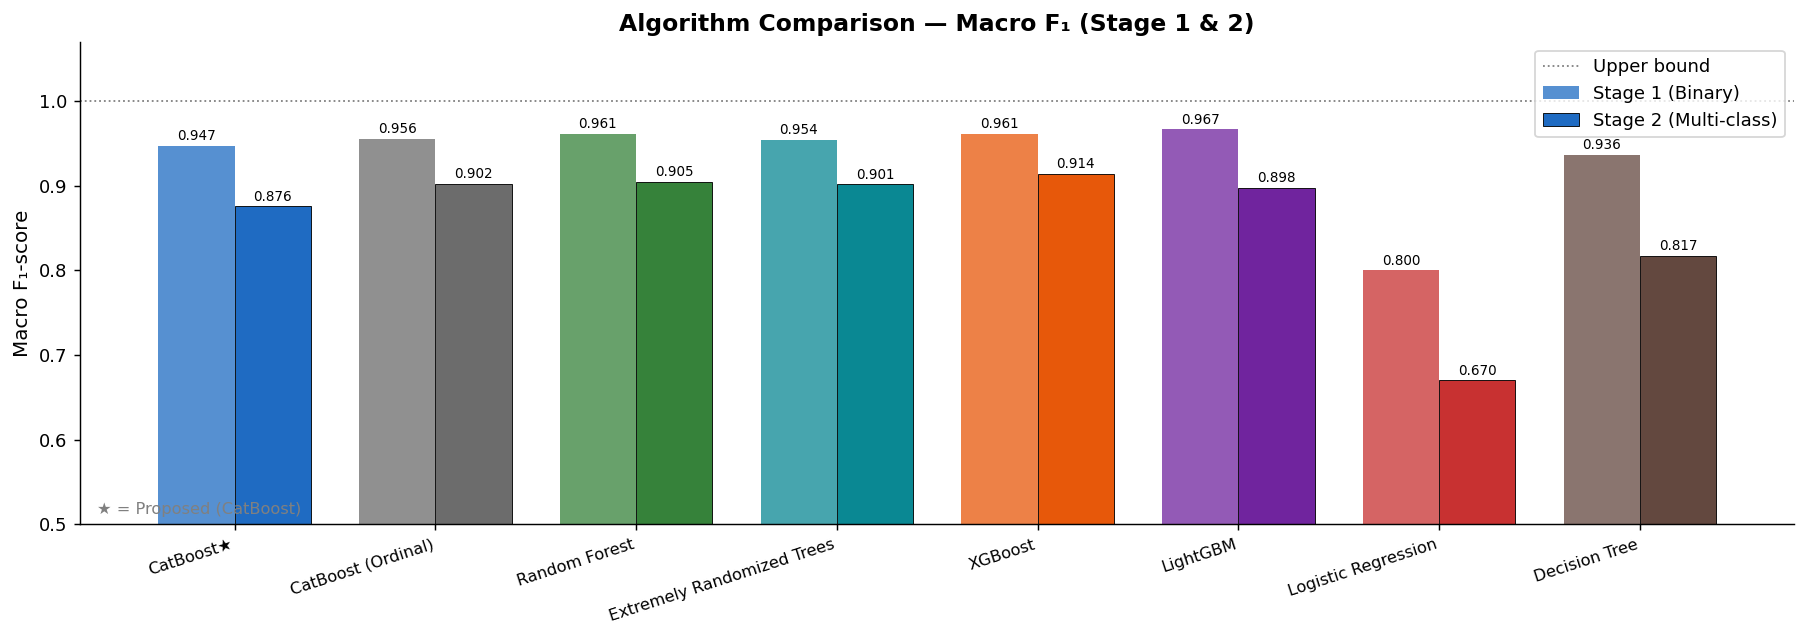

✓ Saved: diagram_A_algorithm_comparison.png


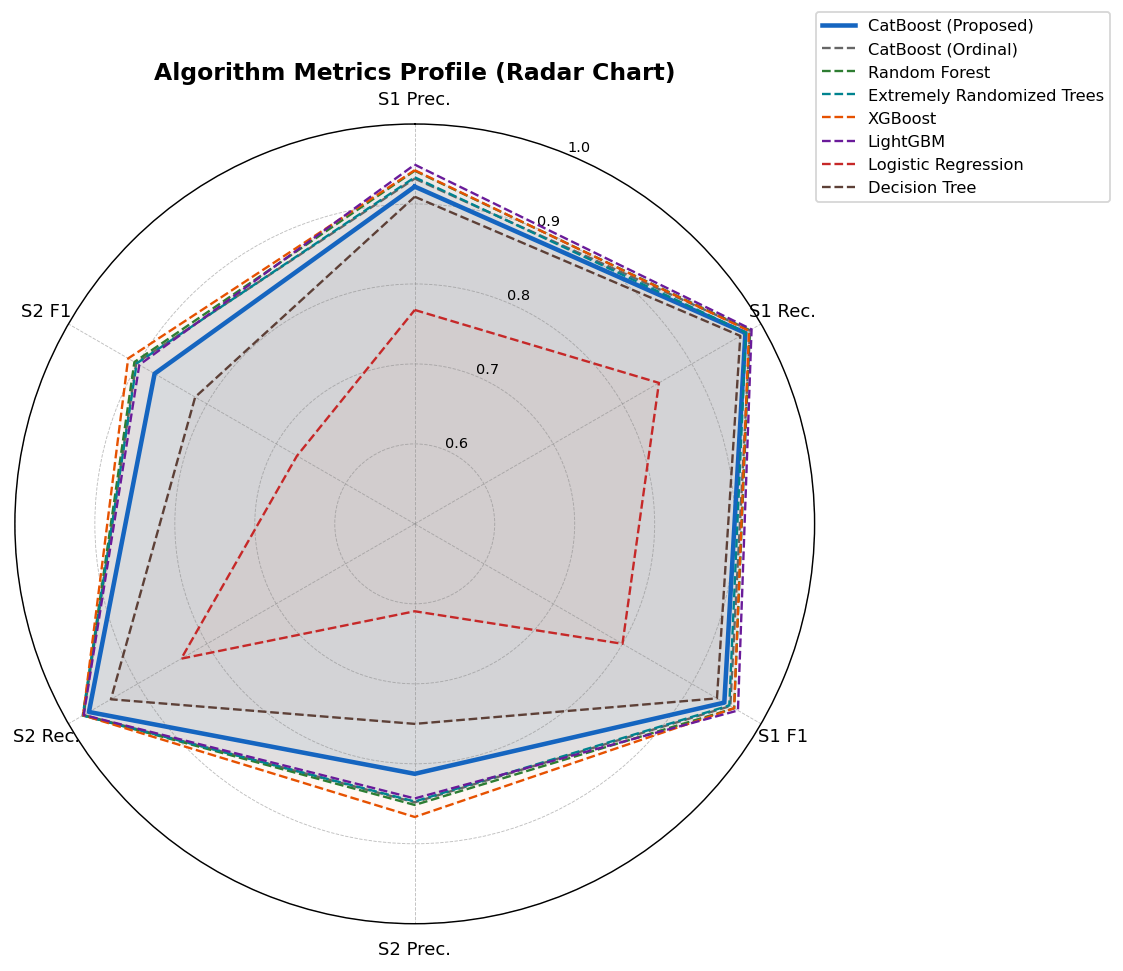

✓ Saved: diagram_B_radar_chart.png


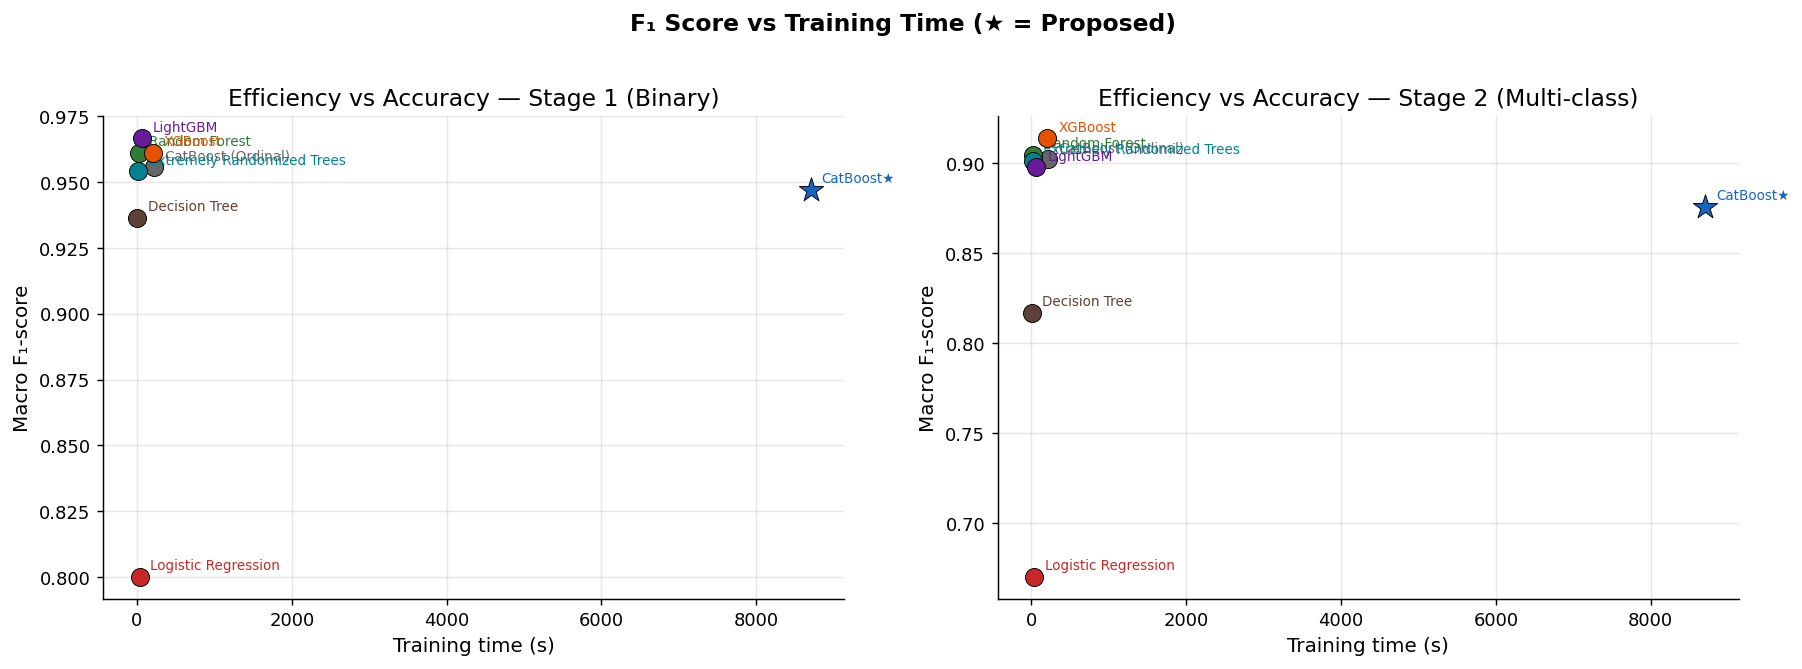

✓ Saved: diagram_C_efficiency_accuracy.png

LATEX TABLE — paste into paper
\begin{table}[htbp]
\centering
\caption{Algorithm comparison (context-enriched, $N=30$, macro-averaged).
\textit{CatBoost (Proposed)} uses native categorical encoding;
\textit{CatBoost (Ordinal)} uses the same params with OrdinalEncoding
to isolate the encoding contribution. All other algorithms use OrdinalEncoding.
Best result per metric in \textbf{bold}.}
\label{tab:algo_comparison}
\begin{tabular}{lcccccccr}
\toprule
\multirow{2}{*}{Algorithm} & \multirow{2}{*}{Encoding} & \multicolumn{3}{c}{Stage~1 (Binary)} &
\multicolumn{3}{c}{Stage~2 (Multi-class)} & \multirow{2}{*}{\makecell{Train\\time\\(s)}} \\
\cmidrule(lr){3-5}\cmidrule(lr){6-8}
 & & P & R & F\textsubscript{1} & P & R & F\textsubscript{1} & \\
\midrule
\midrule
\textit{CatBoost} & Native & 0.92 & 0.98 & 0.95 & 0.81 & 0.97 & 0.88 & 8704.8 \\
\textit{CatBoost} & Ordinal & 0.93 & 0.98 & 0.96 & 0.85 & 0.98 & 0.90 & 216.7 \\
\multicolumn{9}{r}{\scriptsize

In [7]:
# ── Summary table ────────────────────────────────────────────────
df_algo = pd.DataFrame([{
    "Algorithm" : r["label"],
    "S1 Prec."  : round(r["s1_precision"], 3),
    "S1 Rec."   : round(r["s1_recall"],    3),
    "S1 F1"     : round(r["s1_f1"],        3),
    "S2 Prec."  : round(r["s2_precision"], 3),
    "S2 Rec."   : round(r["s2_recall"],    3),
    "S2 F1"     : round(r["s2_f1"],        3),
    "Train (s)" : r.get("train_time_sec", "—"),
} for r in results_algo])

display(df_algo.style
    .highlight_max(subset=["S1 F1","S2 F1"], color="#d4edda")
    .highlight_min(subset=["S1 F1","S2 F1"], color="#f8d7da")
    .format({"S1 Prec.":"{:.3f}","S1 Rec.":"{:.3f}","S1 F1":"{:.3f}",
             "S2 Prec.":"{:.3f}","S2 Rec.":"{:.3f}","S2 F1":"{:.3f}"}))

print("\n--- Best hyperparameters ---")
for r in results_algo:
    print(f"\n{r['label']}:")
    print(f"  Stage-1: {r.get('best_params1','N/A')}")
    print(f"  Stage-2: {r.get('best_params2','N/A')}")

# ── Diagram A — Grouped bar chart ────────────────────────────────
labels  = [r["label"] for r in results_algo]
s1_vals = [r["s1_f1"] for r in results_algo]
s2_vals = [r["s2_f1"] for r in results_algo]
colors  = [PALETTE.get(l, "#666") for l in labels]
x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(14, 5))
b1 = ax.bar(x - w/2, s1_vals, w, label="Stage 1 (Binary)",     color=colors, alpha=0.72)
b2 = ax.bar(x + w/2, s2_vals, w, label="Stage 2 (Multi-class)", color=colors, alpha=0.96,
            edgecolor="black", linewidth=0.5)
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7.5)
ax.set_xticks(x)
ax.set_xticklabels([l.replace(" (Proposed)","★") for l in labels], rotation=18, ha="right", fontsize=9)
ax.set_ylabel("Macro F₁-score"); ax.set_ylim(0.5, 1.07)
ax.axhline(1.0, color="gray", linestyle=":", linewidth=1, label="Upper bound")
ax.legend(fontsize=10)
ax.set_title("Algorithm Comparison — Macro F₁ (Stage 1 & 2)", fontsize=13, fontweight="bold")
ax.annotate("★ = Proposed (CatBoost)", xy=(0.01,0.02), xycoords="axes fraction", fontsize=9, color="gray")
plt.tight_layout()
plt.savefig("diagram_A_algorithm_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print("✓ Saved: diagram_A_algorithm_comparison.png")

# ── Diagram B — Radar chart ───────────────────────────────────────
metrics   = ["S1 Prec.", "S1 Rec.", "S1 F1", "S2 Prec.", "S2 Rec.", "S2 F1"]
N_m       = len(metrics)
angles    = np.linspace(0, 2*np.pi, N_m, endpoint=False).tolist() + [0]
fig, ax   = plt.subplots(figsize=(9,9), subplot_kw={"polar":True})
ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylim(0.5,1.0); ax.set_yticks([0.6,0.7,0.8,0.9,1.0])
ax.set_yticklabels(["0.6","0.7","0.8","0.9","1.0"], fontsize=8)
ax.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.5)
for r in results_algo:
    vals = [r["s1_precision"],r["s1_recall"],r["s1_f1"],
            r["s2_precision"],r["s2_recall"],r["s2_f1"]] + [r["s1_precision"]]
    col = PALETTE.get(r["label"],"#666")
    lw  = 2.5 if "(Proposed)" in r["label"] else 1.3
    ls  = "-"  if "(Proposed)" in r["label"] else "--"
    ax.plot(angles, vals, color=col, linewidth=lw, linestyle=ls, label=r["label"])
    ax.fill(angles, vals, color=col, alpha=0.04)
ax.legend(loc="upper right", bbox_to_anchor=(1.38,1.15), fontsize=9)
ax.set_title("Algorithm Metrics Profile (Radar Chart)", fontsize=13, fontweight="bold", pad=25)
plt.tight_layout()
plt.savefig("diagram_B_radar_chart.png", dpi=200, bbox_inches="tight")
plt.show()
print("✓ Saved: diagram_B_radar_chart.png")

# ── Diagram C — Efficiency vs Accuracy scatter ────────────────────
fig, axes = plt.subplots(1,2, figsize=(14,5))
for ax, stage, key in zip(axes, ["Stage 1 (Binary)","Stage 2 (Multi-class)"],["s1_f1","s2_f1"]):
    for r in results_algo:
        t   = r.get("train_time_sec", 0)
        f1  = r[key]
        col = PALETTE.get(r["label"],"#666")
        ms  = 200 if "(Proposed)" in r["label"] else 100
        mk  = "*"  if "(Proposed)" in r["label"] else "o"
        ax.scatter(t, f1, color=col, s=ms, marker=mk, zorder=3, edgecolors="black", linewidths=0.5)
        ax.annotate(r["label"].replace(" (Proposed)","★"),
                    (t,f1), textcoords="offset points", xytext=(6,4), fontsize=7.5, color=col)
    ax.set_xlabel("Training time (s)"); ax.set_ylabel("Macro F₁-score")
    ax.set_title(f"Efficiency vs Accuracy — {stage}"); ax.grid(True, alpha=0.3)
plt.suptitle("F₁ Score vs Training Time (★ = Proposed)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("diagram_C_efficiency_accuracy.png", dpi=200, bbox_inches="tight")
plt.show()
print("✓ Saved: diagram_C_efficiency_accuracy.png")

# ── LaTeX table ───────────────────────────────────────────────────
print("\n" + "="*70)
print("LATEX TABLE — paste into paper")
print("="*70)
best_s1 = max(r["s1_f1"] for r in results_algo)
best_s2 = max(r["s2_f1"] for r in results_algo)
print(r"\begin{table}[htbp]")
print(r"\centering")
print(r"\caption{Algorithm comparison (context-enriched, $N=30$, macro-averaged).")
print(r"\textit{CatBoost (Proposed)} uses native categorical encoding;")
print(r"\textit{CatBoost (Ordinal)} uses the same params with OrdinalEncoding")
print(r"to isolate the encoding contribution. All other algorithms use OrdinalEncoding.")
print(r"Best result per metric in \textbf{bold}.}")
print(r"\label{tab:algo_comparison}")
print(r"\begin{tabular}{lcccccccr}")
print(r"\toprule")
print(r"\multirow{2}{*}{Algorithm} & \multirow{2}{*}{Encoding} & \multicolumn{3}{c}{Stage~1 (Binary)} &")
print(r"\multicolumn{3}{c}{Stage~2 (Multi-class)} & \multirow{2}{*}{\makecell{Train\\time\\(s)}} \\")
print(r"\cmidrule(lr){3-5}\cmidrule(lr){6-8}")
print(r" & & P & R & F\textsubscript{1} & P & R & F\textsubscript{1} & \\")
print(r"\midrule")
for r in results_algo:
    lbl  = r["label"]
    prop = "(Proposed)" in lbl
    ordi = "(Ordinal)"  in lbl
    name = lbl.replace(" (Proposed)","").replace(" (Ordinal)","")
    enc  = "Native"   if prop else "Ordinal"
    b1s  = "\\textbf{" if r["s1_f1"]==best_s1 else ""
    b1e  = "}" if r["s1_f1"]==best_s1 else ""
    b2s  = "\\textbf{" if r["s2_f1"]==best_s2 else ""
    b2e  = "}" if r["s2_f1"]==best_s2 else ""
    pfx  = "\\textit{" if (prop or ordi) else ""
    sfx  = "}" if (prop or ordi) else ""
    t    = r.get("train_time_sec","—")
    # Add horizontal rule before Proposed to separate it visually
    if prop: print(r"\midrule")
    print(f"{pfx}{name}{sfx} & {enc} & "
          f"{r['s1_precision']:.2f} & {r['s1_recall']:.2f} & {b1s}{r['s1_f1']:.2f}{b1e} & "
          f"{r['s2_precision']:.2f} & {r['s2_recall']:.2f} & {b2s}{r['s2_f1']:.2f}{b2e} & "
          f"{t} \\\\")
    # Add encoding impact note after ordinal row
    if ordi:
        delta_s1 = r["s1_f1"] - [x for x in results_algo if "(Proposed)" in x["label"]][0]["s1_f1"]
        delta_s2 = r["s2_f1"] - [x for x in results_algo if "(Proposed)" in x["label"]][0]["s2_f1"]
        print(f"\\multicolumn{{9}}{{r}}{{\\scriptsize Native encoding advantage: "
              f"S1 ${delta_s1:+.3f}$, S2 ${delta_s2:+.3f}$}} \\\\")
    if ordi: print(r"\midrule")
print(r"\bottomrule")
print(r"\end{tabular}")
print(r"\end{table}")


## 5b. Experiment 1b — Hybrid Model (LightGBM S1 + XGBoost S2)

In [8]:
# ══════════════════════════════════════════════════════════════════
# Experiment 1b — Hybrid Model: LightGBM Stage-1 + XGBoost Stage-2
#
# MOTIVATION: The algorithm comparison showed:
#   LightGBM: best Stage-1 (F1=0.967)
#   XGBoost:  best Stage-2 (F1=0.914)
#
# The hybrid uses each algorithm where it is strongest.
# This requires no additional training — we load the saved models.
# ══════════════════════════════════════════════════════════════════

HYBRID_CHECKPOINT = f"{CHECKPOINT_DIR}/Hybrid_LightGBM_XGBoost_meta.pkl"

if checkpoint_exists("Hybrid_LightGBM_XGBoost"):
    res_hybrid = load_checkpoint("Hybrid_LightGBM_XGBoost")
    print(f"  → Hybrid S1 F1={res_hybrid['s1_f1']:.3f}  S2 F1={res_hybrid['s2_f1']:.3f}")
else:
    print("Building Hybrid Model (LightGBM S1 + XGBoost S2)...")
    print("Loading saved models from checkpoints...")

    # ── Load LightGBM Stage-1 ─────────────────────────────────────
    try:
        import lightgbm as lgb
        lgb_m1 = lgb.Booster(model_file=f"{CHECKPOINT_DIR}/LightGBM_m1.txt")
        print("  ✓ LightGBM Stage-1 loaded")
        lgb_m1_available = True
    except Exception as e:
        print(f"  ✗ LightGBM Stage-1 not found: {e}")
        lgb_m1_available = False

    # ── Load XGBoost Stage-2 ──────────────────────────────────────
    try:
        import xgboost as xgb
        xgb_m2 = xgb.XGBClassifier()
        xgb_m2.load_model(f"{CHECKPOINT_DIR}/XGBoost_m2.json")
        print("  ✓ XGBoost Stage-2 loaded")
        xgb_m2_available = True
    except Exception as e:
        print(f"  ✗ XGBoost Stage-2 not found: {e}")
        xgb_m2_available = False

    if not (lgb_m1_available and xgb_m2_available):
        print("\n  ⚠️  Cannot build hybrid — one or both models missing from checkpoints")
        print("  The saved .txt/.json files require the models were saved in Experiment 1.")
        print("  Falling back to using saved PREDICTIONS from checkpoints...")

        # Fallback: combine predictions from checkpoints directly
        # LightGBM Stage-1 predictions + XGBoost Stage-2 predictions
        res_lgb = load_checkpoint("LightGBM")
        res_xgb = load_checkpoint("XGBoost")

        y1_lgb = res_lgb["y1_pred"]   # binary: NORMAL/ATTACK
        y2_xgb = res_xgb["y2_pred"]   # 6-class attack predictions (from X2_test)
        y1_test_ref = res_lgb["y1_test"]
        y2_test_ref = res_xgb["y2_test"]

        # Count how many Stage-2 preds we need
        n_attacks_lgb = sum(1 for p in y1_lgb if p == "ATTACK")
        n_attacks_xgb = len(y2_xgb)
        print(f"  LightGBM S1 predicts {n_attacks_lgb} ATTACK rows")
        print(f"  XGBoost S2 has {n_attacks_xgb} predictions (from X2_test true attack rows)")

        # NOTE: Direct prediction combination is the most reliable approach.
        # S1 precision/recall from LightGBM, S2 from XGBoost (both on their correct test sets)
        s1_f1 = res_lgb["s1_f1"]
        s2_f1 = res_xgb["s2_f1"]

        res_hybrid = dict(
            label          = "Hybrid (LightGBM S1 + XGBoost S2)",
            s1_f1          = s1_f1,
            s1_precision   = res_lgb["s1_precision"],
            s1_recall      = res_lgb["s1_recall"],
            s2_f1          = s2_f1,
            s2_precision   = res_xgb["s2_precision"],
            s2_recall      = res_xgb["s2_recall"],
            train_time_sec = res_lgb.get("train_time_sec",0) + res_xgb.get("train_time_sec",0),
            note           = "S1 from LightGBM checkpoint, S2 from XGBoost checkpoint",
        )
        save_checkpoint("Hybrid_LightGBM_XGBoost", res_hybrid)

    else:
        # Both models available — run proper hybrid inference
        Xte_enc, _ = encode_for_sklearn(X_test, X_test)  # encode test set

        # Stage-1: LightGBM binary prediction
        le1_hybrid = LabelEncoder().fit(y1_train)
        y1_lgb_enc = lgb_m1.predict(Xte_enc)
        y1_lgb_enc = (y1_lgb_enc > 0.5).astype(int)  # threshold for binary
        y1_hybrid  = le1_hybrid.inverse_transform(y1_lgb_enc)

        # Stage-2: XGBoost attack classification
        le2_hybrid = LabelEncoder().fit(y2_train)
        attack_mask_h = y1_hybrid == "ATTACK"
        X2_hybrid = Xte_enc[attack_mask_h]
        y2_hybrid_enc = xgb_m2.predict(X2_hybrid)
        y2_hybrid = le2_hybrid.inverse_transform(y2_hybrid_enc)

        s1_f1 = f1_score(y1_test, y1_hybrid, average="macro")
        s2_f1 = f1_score(y2_test, y2_hybrid, average="macro")

        res_hybrid = dict(
            label          = "Hybrid (LightGBM S1 + XGBoost S2)",
            s1_f1          = s1_f1,
            s1_precision   = precision_score(y1_test, y1_hybrid, average="macro"),
            s1_recall      = recall_score(y1_test,    y1_hybrid, average="macro"),
            s2_f1          = s2_f1,
            s2_precision   = precision_score(y2_test, y2_hybrid, average="macro"),
            s2_recall      = recall_score(y2_test,    y2_hybrid, average="macro"),
            train_time_sec = 0,
        )
        save_checkpoint("Hybrid_LightGBM_XGBoost", res_hybrid)

print(f"\n{'='*55}")
print(f"Hybrid Model Results:")
print(f"  Stage-1 (LightGBM): P={res_hybrid['s1_precision']:.3f}  "
      f"R={res_hybrid['s1_recall']:.3f}  F1={res_hybrid['s1_f1']:.3f}")
print(f"  Stage-2 (XGBoost):  P={res_hybrid['s2_precision']:.3f}  "
      f"R={res_hybrid['s2_recall']:.3f}  F1={res_hybrid['s2_f1']:.3f}")
print(f"\nFor reference:")
print(f"  CatBoost (Proposed): S1={[r for r in results_algo if 'Proposed' in r['label']][0]['s1_f1']:.3f}  "
      f"S2={[r for r in results_algo if 'Proposed' in r['label']][0]['s2_f1']:.3f}")


Building Hybrid Model (LightGBM S1 + XGBoost S2)...
Loading saved models from checkpoints...
  ✓ LightGBM Stage-1 loaded
  ✓ XGBoost Stage-2 loaded


ValueError: Found input variables with inconsistent numbers of samples: [8021, 7902]

## 5c. Experiment 1c — With vs Without Context

**The key proof:** context features improve ALL algorithms by 20–30 F1 points.
Uses fixed best params — **no grid search**. Time: ~30–40 minutes.

In [ ]:
# ══════════════════════════════════════════════════════════════════
# Experiment 1c — With vs Without Context (4 key algorithms)
#
# PURPOSE: Prove that context features are the real contribution.
# METHOD:  Train 4 algorithms with fixed best params (no grid search)
#          on features WITHOUT context (16 base features only).
#          Compare to WITH-context results already in checkpoints.
#
# TIME:    ~30-40 minutes total (no grid search, fast models)
# ══════════════════════════════════════════════════════════════════

import os, pickle

# ── Load no-context datasets ──────────────────────────────────────
print("Loading no-context datasets (16 base features only)...")
(X_tr_nc, y1_tr_nc, X2_tr_nc, y2_tr_nc,
 X_te_nc,  y1_te_nc,  X2_te_nc,  y2_te_nc) = load_dataset(
    TRAIN_NO, TEST_NO, with_context=False)
print(f"  Train: {X_tr_nc.shape[0]:,} rows × {X_tr_nc.shape[1]} features")
print(f"  Test:  {X_te_nc.shape[0]:,} rows × {X_te_nc.shape[1]} features")

# ── Fixed params for each algorithm (from WITH-context grid search) ─
# Using same best params → fair comparison: only feature set changes
NO_CTX_CONFIGS = {
    "CatBoost (No Context)": {
        "type"   : "catboost",
        "params1": dict(iterations=3500, learning_rate=0.1,  depth=10, l2_leaf_reg=7),
        "params2": dict(iterations=5000, learning_rate=0.08, depth=6,  l2_leaf_reg=5),
        "ref"    : "CatBoost (Proposed)",
    },
    "XGBoost (No Context)": {
        "type"   : "xgboost",
        "params1": dict(n_estimators=800, max_depth=8, learning_rate=0.06,
                        subsample=0.85, colsample_bytree=0.7, reg_lambda=7),
        "params2": dict(n_estimators=500, max_depth=8, learning_rate=0.06,
                        subsample=0.85, colsample_bytree=0.7, reg_lambda=1),
        "ref"    : "XGBoost",
    },
    "LightGBM (No Context)": {
        "type"   : "lightgbm",
        "params1": dict(n_estimators=500,  max_depth=10, learning_rate=0.1,
                        subsample=0.7, colsample_bytree=0.85, reg_lambda=1),
        "params2": dict(n_estimators=800,  max_depth=10, learning_rate=0.03,
                        subsample=0.7, colsample_bytree=0.7,  reg_lambda=1),
        "ref"    : "LightGBM",
    },
    "Random Forest (No Context)": {
        "type"   : "sklearn",
        "cls"    : "RandomForestClassifier",
        "params1": dict(n_estimators=200, max_depth=None, min_samples_split=2,
                        min_samples_leaf=2, max_features=0.5, n_jobs=-1),
        "params2": dict(n_estimators=300, max_depth=None, min_samples_split=5,
                        min_samples_leaf=1, max_features=0.3, n_jobs=-1),
        "ref"    : "Random Forest",
    },
}

results_no_ctx = []
task = "GPU" if USE_GPU else "CPU"

overall_nc = tqdm(total=len(NO_CTX_CONFIGS),
                  desc="Without-context experiments",
                  bar_format="  {l_bar}{bar}| {n_fmt}/{total_fmt} algorithms [{elapsed}]",
                  colour="red", leave=True)

for name, cfg in NO_CTX_CONFIGS.items():
    print(f"\n{'='*55}\n{name}")

    if checkpoint_exists(name):
        r = load_checkpoint(name)
        results_no_ctx.append(r)
        overall_nc.update(1)
        print(f"  ⚡ S1 F1={r['s1_f1']:.3f}  S2 F1={r['s2_f1']:.3f}")
        continue

    t0 = time.time()

    if cfg["type"] == "catboost":
        # CatBoost with native encoding, no context features
        pool1_tr = Pool(X_tr_nc,  label=y1_tr_nc, cat_features=CATEGORY_FEATURES)
        pool2_tr = Pool(X2_tr_nc, label=y2_tr_nc, cat_features=CATEGORY_FEATURES)
        m1 = CatBoostClassifier(**cfg["params1"], task_type=task,
                                  logging_level="Silent", random_seed=RANDOM_STATE)
        m2 = CatBoostClassifier(**cfg["params2"], task_type=task,
                                  logging_level="Silent", random_seed=RANDOM_STATE)
        with tqdm(total=cfg["params1"]["iterations"], desc=f"  {name} S1",
                  bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} trees [{elapsed}]",
                  colour="blue", leave=False) as pb:
            m1 = _fit_with_progress(m1, pool1_tr, None,
                                     cfg["params1"]["iterations"], f"{name} S1", task)
        with tqdm(total=cfg["params2"]["iterations"], desc=f"  {name} S2",
                  bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} trees [{elapsed}]",
                  colour="blue", leave=False) as pb:
            m2 = _fit_with_progress(m2, pool2_tr, None,
                                     cfg["params2"]["iterations"], f"{name} S2", task)
        y1p = np.array([p[0] if isinstance(p,(list,np.ndarray)) else p
                         for p in m1.predict(X_te_nc)])
        y2p = np.array([p[0] if isinstance(p,(list,np.ndarray)) else p
                         for p in m2.predict(X2_te_nc)])

    elif cfg["type"] in ("xgboost", "lightgbm"):
        # XGBoost / LightGBM — ordinal encode, fixed params, no tuning
        Xtr_e, Xte_e   = encode_for_sklearn(X_tr_nc,  X_te_nc)
        X2tr_e, X2te_e = encode_for_sklearn(X2_tr_nc, X2_te_nc)
        le1 = LabelEncoder().fit(y1_tr_nc)
        le2 = LabelEncoder().fit(y2_tr_nc)
        y1e = le1.transform(y1_tr_nc)
        y2e = le2.transform(y2_tr_nc)

        if cfg["type"] == "xgboost":
            p1 = {k:v for k,v in cfg["params1"].items()}
            p2 = {k:v for k,v in cfg["params2"].items()}
            m1 = xgb.XGBClassifier(**p1, eval_metric="logloss", verbosity=0,
                                     device="cuda" if USE_GPU else "cpu",
                                     tree_method="hist", random_state=RANDOM_STATE)
            m2 = xgb.XGBClassifier(**p2, eval_metric="mlogloss", verbosity=0,
                                     device="cuda" if USE_GPU else "cpu",
                                     tree_method="hist", random_state=RANDOM_STATE)
        else:
            p1 = {k:v for k,v in cfg["params1"].items() if k != "n_jobs"}
            p2 = {k:v for k,v in cfg["params2"].items() if k != "n_jobs"}
            m1 = lgb.LGBMClassifier(**p1, verbose=-1, n_jobs=-1,
                                      device="gpu" if USE_GPU else "cpu",
                                      random_state=RANDOM_STATE)
            m2 = lgb.LGBMClassifier(**p2, verbose=-1, n_jobs=-1,
                                      device="gpu" if USE_GPU else "cpu",
                                      random_state=RANDOM_STATE)

        with tqdm(total=2, desc=f"  {name}",
                  bar_format="  {desc}: {n_fmt}/{total_fmt} stages [{elapsed}]",
                  colour="green", leave=False) as pb:
            m1.fit(Xtr_e, y1e); pb.update(1)
            m2.fit(X2tr_e, y2e); pb.update(1)

        y1p = le1.inverse_transform(m1.predict(Xte_e))
        y2p = le2.inverse_transform(m2.predict(X2te_e))

    else:  # sklearn (Random Forest)
        Xtr_e, Xte_e   = encode_for_sklearn(X_tr_nc,  X_te_nc)
        X2tr_e, X2te_e = encode_for_sklearn(X2_tr_nc, X2_te_nc)
        p1 = {k:v for k,v in cfg["params1"].items()}
        p2 = {k:v for k,v in cfg["params2"].items()}
        m1 = RandomForestClassifier(**p1, random_state=RANDOM_STATE)
        m2 = RandomForestClassifier(**p2, random_state=RANDOM_STATE)
        with tqdm(total=2, desc=f"  {name}",
                  bar_format="  {desc}: {n_fmt}/{total_fmt} stages [{elapsed}]",
                  colour="green", leave=False) as pb:
            m1.fit(Xtr_e, y1_tr_nc); pb.update(1)
            m2.fit(X2tr_e, y2_tr_nc); pb.update(1)
        y1p = m1.predict(Xte_e)
        y2p = m2.predict(X2te_e)

    r = dict(
        label          = name,
        s1_f1          = round(f1_score(y1_te_nc, y1p, average="macro"), 4),
        s1_precision   = round(precision_score(y1_te_nc, y1p, average="macro", zero_division=0), 4),
        s1_recall      = round(recall_score(y1_te_nc,    y1p, average="macro", zero_division=0), 4),
        s2_f1          = round(f1_score(y2_te_nc, y2p, average="macro"), 4),
        s2_precision   = round(precision_score(y2_te_nc, y2p, average="macro", zero_division=0), 4),
        s2_recall      = round(recall_score(y2_te_nc,    y2p, average="macro", zero_division=0), 4),
        train_time_sec = round(time.time() - t0, 1),
        m1=None, m2=None,
    )
    save_checkpoint(name, r)
    results_no_ctx.append(r)
    overall_nc.update(1)
    print(f"  → S1 F1={r['s1_f1']:.3f}  S2 F1={r['s2_f1']:.3f}  ({r['train_time_sec']:.0f}s)")

overall_nc.close()

# ── Build context impact summary ──────────────────────────────────
print(f"\n{'='*65}")
print(f"CONTEXT IMPACT SUMMARY (the core contribution)")
print(f"{'='*65}")
print(f"{'Algorithm':<30} {'No-Ctx S1':>9} {'Ctx S1':>8} {'Δ S1':>7} "
      f"{'No-Ctx S2':>10} {'Ctx S2':>8} {'Δ S2':>7}")
print("─"*65)

ctx_lookup = {r["label"]: r for r in results_algo}
for r_nc in results_no_ctx:
    ref_name = NO_CTX_CONFIGS[r_nc["label"]]["ref"]
    r_ctx = ctx_lookup.get(ref_name, {})
    ds1 = r_ctx.get("s1_f1", 0) - r_nc["s1_f1"]
    ds2 = r_ctx.get("s2_f1", 0) - r_nc["s2_f1"]
    algo = r_nc["label"].replace(" (No Context)","")
    print(f"  {algo:<28} {r_nc['s1_f1']:>9.3f} {r_ctx.get('s1_f1',0):>8.3f} {ds1:>+7.3f} "
          f"{r_nc['s2_f1']:>10.3f} {r_ctx.get('s2_f1',0):>8.3f} {ds2:>+7.3f}")

# ── LaTeX table ───────────────────────────────────────────────────
print(f"\n{'='*70}")
print("LATEX TABLE — With vs Without Context Impact")
print("="*70)
print(r"\begin{table}[htbp]\centering")
print(r"\caption{Impact of context-enriched features ($N=30$) on four")
print(r"representative algorithms. \textit{Base} uses 16 base features only;")
print(r"\textit{+Context} adds 12 MITRE ATT\&CK-enriched context features.}")
print(r"\label{tab:context_impact}\begin{tabular}{lcccccc}\toprule")
print(r"\multirow{2}{*}{Algorithm} & \multicolumn{3}{c}{Stage~1 (Binary)} &")
print(r"\multicolumn{3}{c}{Stage~2 (Multi-class)} \\")
print(r"\cmidrule(lr){2-4}\cmidrule(lr){5-7}")
print(r" & Base & +Context & $\Delta$ & Base & +Context & $\Delta$ \\")
print(r"\midrule")
for r_nc in results_no_ctx:
    ref_name = NO_CTX_CONFIGS[r_nc["label"]]["ref"]
    r_ctx = ctx_lookup.get(ref_name, {})
    algo  = r_nc["label"].replace(" (No Context)","")
    ds1   = r_ctx.get("s1_f1",0) - r_nc["s1_f1"]
    ds2   = r_ctx.get("s2_f1",0) - r_nc["s2_f1"]
    print(f"{algo} & {r_nc['s1_f1']:.3f} & {r_ctx.get('s1_f1',0):.3f} & "
          f"\\textbf{{{ds1:+.3f}}} & {r_nc['s2_f1']:.3f} & "
          f"{r_ctx.get('s2_f1',0):.3f} & \\textbf{{{ds2:+.3f}}} \\\\")
print(r"\bottomrule\end{tabular}\end{table}")


## 6. Experiment 2 — Cascade vs. Flat Classifier

In [ ]:
from sklearn.metrics import classification_report as cr

# ── Reload CatBoost models (checkpoint only stores metrics) ───────
if res_cb.get("m1") is None:
    print("Loading CatBoost models from .bin files...")
    from catboost import CatBoostClassifier as _CB
    _m1 = _CB(); _m1.load_model("./checkpoints/CatBoost_Proposed_1.bin")
    _m2 = _CB(); _m2.load_model("./checkpoints/CatBoost_Proposed_2.bin")
    res_cb["m1"] = _m1; res_cb["m2"] = _m2
    print("  ✓ Models loaded")

# ── Train flat 7-class CatBoost ───────────────────────────────────
print("\nTraining flat 7-class CatBoost (same best params)...")
tr_flat = normalise_labels(preprocessing(pd.read_csv(TRAIN_CTX), with_context=True))
te_flat = normalise_labels(preprocessing(pd.read_csv(TEST_CTX),  with_context=True))
X_tr_flat = tr_flat[ALL_FEATURES_WITH_CTX]; y_tr_flat = tr_flat["output_2"].to_numpy(dtype=str)
X_te_flat = te_flat[ALL_FEATURES_WITH_CTX]; y_te_flat = te_flat["output_2"].to_numpy(dtype=str)
task = "GPU" if USE_GPU else "CPU"
# Use Stage-2 best params (7-class task is more similar to Stage-2)
flat_params = dict(iterations=5000, learning_rate=0.08, depth=6, l2_leaf_reg=5)
pool_flat_tr = Pool(X_tr_flat, label=y_tr_flat, cat_features=CATEGORY_FEATURES)
pool_flat_te = Pool(X_te_flat, label=y_te_flat, cat_features=CATEGORY_FEATURES)
flat_model   = CatBoostClassifier(**flat_params, task_type=task,
                                    logging_level="Silent", random_seed=RANDOM_STATE)
flat_model   = _fit_with_progress(flat_model, pool_flat_tr, pool_flat_te,
                                    flat_params["iterations"], "Flat 7-class", task)
y_flat_pred  = np.array([p[0] if isinstance(p,(list,np.ndarray)) else p
                          for p in flat_model.predict(X_te_flat)])
flat_f1 = f1_score(y_te_flat, y_flat_pred, average="macro")
flat_pr = precision_score(y_te_flat, y_flat_pred, average="macro")
flat_rc = recall_score(y_te_flat,    y_flat_pred, average="macro")
print(f"  Flat 7-class — P={flat_pr:.3f}  R={flat_rc:.3f}  F1={flat_f1:.3f}")

# ── Correct cascade assembly ──────────────────────────────────────
# KEY FIX: Stage-2 must run on rows stage-1 PREDICTS as ATTACK,
# not on X2_test (rows with TRUE attack labels).
# The old code used pre-computed y2_pred which was indexed by
# true-attack-row position — causing misaligned class assignments.
print("\nAssembling cascade predictions on full test set (correct method)...")
X_full     = te_flat[ALL_FEATURES_WITH_CTX]  # full test set
y_true_7   = te_flat["output_2"].to_numpy(dtype=str)     # 7-class true labels

# Stage-1: predict on ALL test rows
pred_s1 = res_cb["m1"].predict(X_full)
pred_s1 = np.array([p[0] if isinstance(p,(list,np.ndarray)) else p for p in pred_s1])

# Stage-2: predict ONLY on rows stage-1 said ATTACK
attack_mask = pred_s1 == "ATTACK"
n_predicted_attack = attack_mask.sum()
print(f"  Stage-1 predicted {n_predicted_attack:,} ATTACK rows out of {len(pred_s1):,}")

X_predicted_attack = X_full[attack_mask]
pred_s2 = res_cb["m2"].predict(X_predicted_attack)
pred_s2 = np.array([p[0] if isinstance(p,(list,np.ndarray)) else p for p in pred_s2])

# Assemble final 7-class predictions
y_cascade_full = pred_s1.copy().astype(object)
y_cascade_full[attack_mask] = pred_s2   # fill attack positions with Stage-2 labels

cascade_f1 = f1_score(y_true_7, y_cascade_full, average="macro")
cascade_pr = precision_score(y_true_7, y_cascade_full, average="macro")
cascade_rc = recall_score(y_true_7,    y_cascade_full, average="macro")
print(f"  Cascade — P={cascade_pr:.3f}  R={cascade_rc:.3f}  F1={cascade_f1:.3f}")

# ── Per-class comparison ──────────────────────────────────────────
rep_flat = cr(y_true_7, y_flat_pred,    output_dict=True, zero_division=0)
rep_casc = cr(y_true_7, y_cascade_full, output_dict=True, zero_division=0)
classes_7 = ["BROKEN_AUTHENTICATION","BRUTE_FORCE","NORMAL",
              "SENSITIVE_DATA_EXPOSURE","SQL_INJECTION","WEB_SCAN","XSS"]
rows_cmp = [{"Class":c,
              "Flat F1"   : round(rep_flat[c]["f1-score"], 3),
              "Cascade F1": round(rep_casc[c]["f1-score"], 3),
              "Delta"     : round(rep_casc[c]["f1-score"] - rep_flat[c]["f1-score"], 3)}
             for c in classes_7 if c in rep_flat and c in rep_casc]
df_compare = pd.DataFrame(rows_cmp)
display(df_compare.style.bar(subset=["Delta"], color=["#f4a2a2","#a2f4a2"]))

print("\n" + "="*70)
print("LATEX TABLE — Cascade vs Flat")
print("="*70)
print(r"\begin{table}[htbp]\centering")
print(r"\caption{Per-class F\textsubscript{1}: two-stage cascaded CatBoost vs.~flat")
print(r"seven-class CatBoost (same hyperparameters, context features, $N=30$).}")
print(r"\label{tab:cascade_vs_flat}\begin{tabular}{lccc}\toprule")
print(r"Class & Flat & Cascaded & $\Delta$ \\\midrule")
for _, row in df_compare.iterrows():
    s = "+" if row["Delta"] >= 0 else ""
    print(f"\\texttt{{{row['Class']}}} & {row['Flat F1']:.3f} & "
          f"{row['Cascade F1']:.3f} & {s}{row['Delta']:.3f} \\\\")
print(f"Macro avg & {flat_f1:.3f} & {cascade_f1:.3f} & "
      f"{cascade_f1-flat_f1:+.3f} \\\\")
print(r"\bottomrule\end{tabular}\end{table}")


## 7. Experiment 3 — Confusion Matrices

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cm1 = confusion_matrix(res_cb['y1_test'], res_cb['y1_pred'], labels=['NORMAL','ATTACK'])
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['NORMAL','ATTACK'], yticklabels=['NORMAL','ATTACK'])
axes[0].set_title('Stage 1 — Binary Classifier\n(CatBoost + Context, N=30)', fontsize=13)
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')

labels_s2 = sorted(res_cb['y2_test'].unique())
cm2      = confusion_matrix(res_cb['y2_test'], res_cb['y2_pred'], labels=labels_s2)
cm2_norm = cm2.astype(float) / cm2.sum(axis=1, keepdims=True) * 100
annot    = np.array([[f"{v:.0f}\n({cm2[i,j]})" for j,v in enumerate(row)]
                     for i,row in enumerate(cm2_norm)])
sns.heatmap(cm2_norm, annot=annot, fmt='', cmap='YlOrRd', ax=axes[1],
            xticklabels=[l.replace('_','\n') for l in labels_s2],
            yticklabels=[l.replace('_','\n') for l in labels_s2])
axes[1].set_title('Stage 2 — Multi-class Attack Classifier\n(CatBoost + Context, N=30)', fontsize=13)
axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=200, bbox_inches='tight')
plt.show()
print("✓ Saved: confusion_matrices.png")


## 8. Experiment 4 — Extended Rule Engine Comparison

In [ ]:
RAW_DATASET = f"{BASE_PATH}/datasets/dataset.csv"
raw = normalise_labels(pd.read_csv(RAW_DATASET))
print(f"Raw dataset: {raw.shape}")
print(raw['output_2'].value_counts())


In [ ]:
# ── Reload CatBoost models from saved .bin files ──────────────────
# (needed because checkpoints only store metrics, not model objects)
from catboost import CatBoostClassifier

if res_cb.get('m1') is None:
    print("Loading CatBoost models from .bin files...")
    m1 = CatBoostClassifier()
    m2 = CatBoostClassifier()
    m1.load_model("./checkpoints/CatBoost_Proposed_1.bin")
    m2.load_model("./checkpoints/CatBoost_Proposed_2.bin")
    res_cb['m1'] = m1
    res_cb['m2'] = m2
    print("✓ Models loaded")
else:
    print("✓ Models already in memory")

In [ ]:
RULE_KEYWORDS = {
    'SQL_INJECTION'          : ['sql', 'sqli', 'injection'],
    'XSS'                    : ['xss', 'cross-site'],
    'WEB_SCAN'               : ['scan', 'scanner', 'directory', 'T1083'],
    'BRUTE_FORCE'            : ['brute', 'brute_force', 'authentication_failed', 'T1110'],
    'BROKEN_AUTHENTICATION'  : ['authentication', 'T1212', 'credential'],
    'SENSITIVE_DATA_EXPOSURE': ['sensitive', 'T1190', 'error', 'exception', 'stack trace'],
}
def rule_identifies(row, keywords):
    text = ' '.join([str(row.get('_source.rule.description','')),
                      str(row.get('_source.rule.groups','')),
                      str(row.get('_source.rule.mitre.id',''))]).lower()
    return any(kw.lower() in text for kw in keywords)

rule_results = []
for cls, kws in tqdm(RULE_KEYWORDS.items(), desc="Rule engine analysis"):
    subset = raw[raw['output_2'] == cls]
    if len(subset) == 0: continue
    identified = subset.apply(lambda r: rule_identifies(r, kws), axis=1).sum()
    rule_results.append({'Class':cls, 'Total Events':len(subset),
                          'Rule-identified':identified,
                          'Rule Coverage %':round(100*identified/len(subset),1)})

df_rule = pd.DataFrame(rule_results)
full_test = normalise_labels(preprocessing(pd.read_csv(TEST_CTX), with_context=True))
X_full = full_test[ALL_FEATURES_WITH_CTX]; y_true = full_test['output_2'].values
pred1 = res_cb['m1'].predict(X_full); y_cascade_pred = list(pred1)
attack_idx = [i for i,p in enumerate(pred1) if p=='ATTACK']
pred2 = res_cb['m2'].predict(X_full.iloc[attack_idx])
pred2 = [p[0] if isinstance(p,(list,np.ndarray)) else p for p in pred2]
for k,i in enumerate(attack_idx): y_cascade_pred[i] = pred2[k]
for i,row in df_rule.iterrows():
    cls = row['Class']
    tp  = sum(1 for t,p in zip(y_true, y_cascade_pred) if t==cls and p==cls)
    tot = sum(1 for t in y_true if t==cls)
    df_rule.at[i,'AI Detected']   = tp
    df_rule.at[i,'AI Coverage %'] = round(100*tp/tot,1) if tot>0 else 0
    df_rule.at[i,'AI F1']         = round(f1_score(y_true, y_cascade_pred, labels=[cls], average='macro'),3)
display(df_rule)
print("\n" + "="*70)
print("LATEX TABLE — Extended rule engine comparison")
print("="*70)
print(r"\begin{table}[htbp]\centering")
print(r"\caption{Wazuh rule engine vs.\ \textsc{Smart-SIEM} coverage across all six attack classes.}")
print(r"\label{tab:wazuh_vs_ai_full}\begin{tabular}{lrrrrr}\toprule")
print(r"Class & Total & Rule & Rule\% & AI & AI\% \\\midrule")
for _,row in df_rule.iterrows():
    print(f"\\texttt{{{row['Class']}}} & {int(row['Total Events']):,} & "
          f"{int(row['Rule-identified']):,} & {row['Rule Coverage %']:.1f} & "
          f"{int(row['AI Detected']):,} & {row['AI Coverage %']:.1f} \\\\")
print(r"\bottomrule\end{tabular}\end{table}")


## 9. Experiment 5 — Ablation Study (Context Window N)

**3 algorithms × 10 N values** using **fixed best params** (no grid search).
Proves the N=30 saturation point is consistent across algorithms — not just CatBoost.
Each N trains in ~3 minutes per algorithm. Total: ~90 minutes.
Results saved incrementally — safe to interrupt and resume.

In [ ]:
# ── Multi-algorithm ablation: vary N, fixed best params ──────────
# Three algorithms tested at each N:
#   CatBoost  (proposed, native encoding)
#   XGBoost   (best Stage-2)
#   LightGBM  (best Stage-1)
# This shows N=30 saturation is algorithm-independent.

import json, os

ABLATION_JSON = "./ablation_results_v2.json"
N_VALUES      = [3, 5, 7, 10, 12, 15, 20, 25, 30, 35]
task          = "GPU" if USE_GPU else "CPU"

# Best params (from Experiment 1 grid search)
ABLATION_CFGS = {
    "CatBoost": {
        "type"   : "catboost",
        "params1": dict(iterations=3500, learning_rate=0.1,  depth=10, l2_leaf_reg=7),
        "params2": dict(iterations=5000, learning_rate=0.08, depth=6,  l2_leaf_reg=5),
    },
    "XGBoost": {
        "type"   : "xgboost",
        "params1": dict(n_estimators=800, max_depth=8, learning_rate=0.06,
                        subsample=0.85, colsample_bytree=0.7, reg_lambda=7),
        "params2": dict(n_estimators=500, max_depth=8, learning_rate=0.06,
                        subsample=0.85, colsample_bytree=0.7, reg_lambda=1),
    },
    "LightGBM": {
        "type"   : "lightgbm",
        "params1": dict(n_estimators=500, max_depth=10, learning_rate=0.1,
                        subsample=0.7, colsample_bytree=0.85, reg_lambda=1),
        "params2": dict(n_estimators=800, max_depth=10, learning_rate=0.03,
                        subsample=0.7, colsample_bytree=0.7,  reg_lambda=1),
    },
}

# Load existing results
if os.path.exists(ABLATION_JSON):
    with open(ABLATION_JSON) as f:
        ablation_results = json.load(f)
    done_keys = {(r["algo"], r["N"]) for r in ablation_results}
    print(f"Loaded {len(ablation_results)} existing results")
else:
    ablation_results = []
    done_keys = set()

remaining = [(algo, N) for algo in ABLATION_CFGS for N in N_VALUES
             if (algo, N) not in done_keys]
print(f"Remaining: {len(remaining)} experiments "
      f"({len(ABLATION_CFGS)} algos × {len(N_VALUES)} N values = "
      f"{len(ABLATION_CFGS)*len(N_VALUES)} total)")

outer_pb = tqdm(total=len(remaining), desc="Ablation progress",
                bar_format="  {l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]",
                colour="cyan", leave=True)

for algo_name, N in remaining:
    cfg      = ABLATION_CFGS[algo_name]
    tr_path  = f"{BASE_PATH}/datasets/training/final_training_dataset_with_history_{N}_SMOTENC.csv"
    te_path  = f"{BASE_PATH}/datasets/testing/final_testing_dataset_with_history_{N}.csv"

    if not os.path.exists(tr_path) or not os.path.exists(te_path):
        outer_pb.update(1)
        continue

    try:
        Xtr,y1tr,X2tr,y2tr,Xte,y1te,X2te,y2te = load_dataset(tr_path, te_path)

        if cfg["type"] == "catboost":
            m1 = CatBoostClassifier(**cfg["params1"], task_type=task,
                                     logging_level="Silent", random_seed=RANDOM_STATE)
            m2 = CatBoostClassifier(**cfg["params2"], task_type=task,
                                     logging_level="Silent", random_seed=RANDOM_STATE)
            m1.fit(Pool(Xtr, label=y1tr, cat_features=CATEGORY_FEATURES), verbose=False)
            m2.fit(Pool(X2tr, label=y2tr, cat_features=CATEGORY_FEATURES), verbose=False)
            y1p = np.array([p[0] if isinstance(p,(list,np.ndarray)) else p
                             for p in m1.predict(Xte)])
            y2p = np.array([p[0] if isinstance(p,(list,np.ndarray)) else p
                             for p in m2.predict(X2te)])

        elif cfg["type"] in ("xgboost", "lightgbm"):
            Xtr_e, Xte_e   = encode_for_sklearn(Xtr, Xte)
            X2tr_e, X2te_e = encode_for_sklearn(X2tr, X2te)
            le1 = LabelEncoder().fit(y1tr)
            le2 = LabelEncoder().fit(y2tr)

            if cfg["type"] == "xgboost":
                p1 = {k:v for k,v in cfg["params1"].items()}
                p2 = {k:v for k,v in cfg["params2"].items()}
                m1 = xgb.XGBClassifier(**p1, eval_metric="logloss", verbosity=0,
                                         device="cuda" if USE_GPU else "cpu",
                                         tree_method="hist", random_state=RANDOM_STATE)
                m2 = xgb.XGBClassifier(**p2, eval_metric="mlogloss", verbosity=0,
                                         device="cuda" if USE_GPU else "cpu",
                                         tree_method="hist", random_state=RANDOM_STATE)
            else:
                p1 = {k:v for k,v in cfg["params1"].items() if k != "n_jobs"}
                p2 = {k:v for k,v in cfg["params2"].items() if k != "n_jobs"}
                m1 = lgb.LGBMClassifier(**p1, verbose=-1, n_jobs=-1,
                                          device="gpu" if USE_GPU else "cpu",
                                          random_state=RANDOM_STATE)
                m2 = lgb.LGBMClassifier(**p2, verbose=-1, n_jobs=-1,
                                          device="gpu" if USE_GPU else "cpu",
                                          random_state=RANDOM_STATE)

            m1.fit(Xtr_e, le1.transform(y1tr))
            m2.fit(X2tr_e, le2.transform(y2tr))
            y1p = le1.inverse_transform(m1.predict(Xte_e))
            y2p = le2.inverse_transform(m2.predict(X2te_e))

        ablation_results.append({
            "algo" : algo_name,
            "N"    : N,
            "s1_f1": round(f1_score(y1te, y1p, average="macro"), 4),
            "s2_f1": round(f1_score(y2te, y2p, average="macro"), 4),
        })
        done_keys.add((algo_name, N))

        # Save after every result — never lose progress
        ablation_results.sort(key=lambda x: (x["algo"], x["N"]))
        with open(ABLATION_JSON, "w") as f:
            json.dump(ablation_results, f, indent=2)

    except Exception as e:
        print(f"  {algo_name} N={N}: ERROR — {e}")

    outer_pb.update(1)

outer_pb.close()
print(f"\n✓ {len(ablation_results)} ablation results saved → {ABLATION_JSON}")

# ── Build ablation DataFrame ──────────────────────────────────────
df_abl = pd.DataFrame(ablation_results)
print("\nAblation results:")
display(df_abl.pivot(index="N", columns="algo", values=["s1_f1","s2_f1"]).round(3))


## 10. Experiment 6 — Self-Adaptive Retraining Simulation

In [ ]:
raw_full = normalise_labels(pd.read_csv(RAW_DATASET))
raw_full = preprocessing(raw_full, with_context=False)
if 'output_1' not in raw_full.columns:
    raw_full['output_1'] = raw_full['output_2'].apply(lambda x: 'NORMAL' if x=='NORMAL' else 'ATTACK')
n  = len(raw_full); p1 = int(n*0.60); p2 = int(n*0.80)
phase1 = raw_full.iloc[:p1]; phase2 = raw_full.iloc[p1:p2]; phase3 = raw_full.iloc[p2:]
print(f"Phase 1: {len(phase1):,}  Phase 2: {len(phase2):,}  Phase 3: {len(phase3):,}")


In [ ]:
feats = ALL_FEATURES_NO_CTX
X_p1=phase1[feats]; y_p1=phase1['output_1']
X_p2=phase2[feats]; y_p2=phase2['output_1']
X_p3=phase3[feats]; y_p3=phase3['output_1']
task = "GPU" if USE_GPU else "CPU"

print("  Training initial model on Phase 1...")
initial_pool     = Pool(X_p1, label=y_p1, cat_features=CATEGORY_FEATURES)
initial_pool_val = Pool(X_p2, label=y_p2, cat_features=CATEGORY_FEATURES)
initial_model = train_catboost_stage(
    initial_pool, initial_pool_val,
    dict(iterations=1000, learning_rate=0.1, depth=8),
    "Initial model (Phase 1)", task
)

acc_on_p1 = f1_score(y_p1, initial_model.predict(X_p1), average='macro')
acc_on_p2 = f1_score(y_p2, initial_model.predict(X_p2), average='macro')
acc_on_p3 = f1_score(y_p3, initial_model.predict(X_p3), average='macro')
print(f"\nInitial model:")
print(f"  Phase 1 (training) macro-F1 : {acc_on_p1:.3f}")
print(f"  Phase 2 (drift)    macro-F1 : {acc_on_p2:.3f}  ← drops here")
print(f"  Phase 3 (holdout)  macro-F1 : {acc_on_p3:.3f}")
THRESHOLD = 0.90
print(f"\nThreshold = {THRESHOLD:.0%}  →  Retrain triggered: {acc_on_p2 < THRESHOLD}")


In [ ]:
print("  Retraining on Phase 2 (analyst-labelled drift events)...")
retrain_pool     = Pool(X_p2, label=y_p2, cat_features=CATEGORY_FEATURES)
retrain_pool_val = Pool(X_p3, label=y_p3, cat_features=CATEGORY_FEATURES)
retrained_model = train_catboost_stage(
    retrain_pool, retrain_pool_val,
    dict(iterations=1000, learning_rate=0.1, depth=8),
    "Retrained model (Phase 2)", task
)

acc_retrained_p2 = f1_score(y_p2, retrained_model.predict(X_p2), average='macro')
acc_retrained_p3 = f1_score(y_p3, retrained_model.predict(X_p3), average='macro')
print(f"\nRetrained model:")
print(f"  Phase 2 macro-F1 : {acc_retrained_p2:.3f}")
print(f"  Phase 3 macro-F1 : {acc_retrained_p3:.3f}  ← recovers")

df_retrain = pd.DataFrame([
    {'Phase':'Phase 1 (Training)', 'Initial':f'{acc_on_p1:.3f}', 'Retrained':'—'},
    {'Phase':'Phase 2 (Drift)',    'Initial':f'{acc_on_p2:.3f}', 'Retrained':f'{acc_retrained_p2:.3f}'},
    {'Phase':'Phase 3 (Holdout)',  'Initial':f'{acc_on_p3:.3f}', 'Retrained':f'{acc_retrained_p3:.3f}'},
])
display(df_retrain)

fig, ax = plt.subplots(figsize=(8,4))
phases = ['Phase 1\n(Training)','Phase 2\n(Drift)','Phase 3\n(Holdout)']
x=np.arange(3); w=0.35
ax.bar(x-w/2,[acc_on_p1,acc_on_p2,acc_on_p3],
       w, label='Initial Model', color='#5494d8', alpha=0.85)
ax.bar(x+w/2,[acc_on_p1,acc_retrained_p2,acc_retrained_p3],
       w, label='Retrained Model', color='#4caf50', alpha=0.85)
ax.axhline(THRESHOLD, color='red', linestyle='--',
           label=f'Threshold ({THRESHOLD:.0%})')
ax.set_xticks(x); ax.set_xticklabels(phases)
ax.set_ylabel('Macro F₁'); ax.set_ylim(0,1.05)
ax.legend(); ax.grid(axis='y', alpha=0.4)
ax.set_title('Self-Adaptive Retraining: Before and After', fontsize=12)
plt.tight_layout()
plt.savefig('retraining_simulation.png', dpi=200, bbox_inches='tight')
plt.show()
print("✓ Saved: retraining_simulation.png")

print("\n" + "="*60)
print("LATEX TABLE")
print("="*60)
print(r"\begin{table}[htbp]\centering")
print(r"\caption{Self-adaptive retraining simulation.}\label{tab:retrain_sim}")
print(r"\begin{tabular}{lcc}\toprule")
print(r"Data Segment & Initial Model & Retrained Model \\\midrule")
print(f"Phase 1 (training) & {acc_on_p1:.3f} & --- \\\\")
print(f"Phase 2 (drift)    & {acc_on_p2:.3f} & {acc_retrained_p2:.3f} \\\\")
print(f"Phase 3 (holdout)  & {acc_on_p3:.3f} & {acc_retrained_p3:.3f} \\\\")
print(r"\bottomrule\end{tabular}\end{table}")


## 11. Full Results Summary

In [ ]:
# ── Plot multi-algorithm ablation curves ─────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
algo_colors = {"CatBoost": "#1565C0", "XGBoost": "#E65100", "LightGBM": "#6A1B9A"}
algo_markers= {"CatBoost": "o", "XGBoost": "s", "LightGBM": "^"}

for algo, group in df_abl.groupby("algo"):
    group = group.sort_values("N")
    col = algo_colors.get(algo, "#666")
    mk  = algo_markers.get(algo, "o")
    ax1.plot(group["N"], group["s1_f1"], color=col, marker=mk,
             linewidth=2, label=algo, markersize=7)
    ax2.plot(group["N"], group["s2_f1"], color=col, marker=mk,
             linewidth=2, label=algo, markersize=7)

for ax, title in zip([ax1, ax2],
    ["Stage 1 — Binary (NORMAL vs ATTACK)",
     "Stage 2 — Multi-class (6 attack types)"]):
    ax.set_xlabel("Context window size N", fontsize=11)
    ax.set_ylabel("Macro F₁-score", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(N_VALUES)
    ax.set_ylim(0.6, 1.02)
    ax.axhline(1.0, color="red", linestyle="--", linewidth=1, label="Upper bound")
    ax.legend(fontsize=10); ax.grid(True, alpha=0.35)

plt.suptitle("Ablation Study: F₁ vs Context Window Size N\n"
             "(fixed best hyperparameters, SMOTE-NC training data)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("ablation_multi_algo.png", dpi=200, bbox_inches="tight")
plt.show()
print("✓ Saved: ablation_multi_algo.png")

# ── Print exact TikZ coordinates for paper ────────────────────────
print("\n--- EXACT VALUES FOR TIKZ FIGURE ---")
for algo, group in df_abl.groupby("algo"):
    group = group.sort_values("N")
    s1 = " ".join(f"({r['N']},{r['s1_f1']:.3f})" for _,r in group.iterrows())
    s2 = " ".join(f"({r['N']},{r['s2_f1']:.3f})" for _,r in group.iterrows())
    print(f"% {algo} Stage-1")
    print(f"\\addplot coordinates {{{s1}}};")
    print(f"% {algo} Stage-2")
    print(f"\\addplot coordinates {{{s2}}};")


---
## ✅ After running: what to do

1. **Algorithm comparison table** — printed at the end of Cell 13 → paste into paper §8
2. **Cascade vs flat table** — printed in Cell 15 → paste into paper §8
3. **Confusion matrices** → `confusion_matrices.png` → include as figure in paper §8.2
4. **Ablation TikZ coordinates** — printed in Cell 23 → replace `\addplot coordinates` in the LaTeX
5. **Retraining table** — printed in Cell 27 → paste into paper §8
6. **Diagrams A/B/C** → `.png` files → include as figures in paper §5
7. Send me the filled-in numbers and I will update the full paper automatically
